# evaluation_3prime — bp-resolution 3' RNA-seq profile predictions

Track plots for the region-based 3' RNA-seq model (`slurm_scripts/finetune_joint_k562_3prime.sh`,
job 6061182), checkpoint `11-val_loss=0.85532.ckpt` — the same checkpoint
`evals/evaluate_e2g_3prime.sh` scored, so these figures and that E2G run describe the same weights.

Four tracks per example, all on one shared genomic axis over the model's full 524288 bp input window:

| track | source |
|---|---|
| **Prediction** | decoder output, `(524288, 2)` = [plus, minus], softplus'd |
| **True 3' coverage** | `K562_rnaseq_stranded.npz`, the model's training target |
| **K562 DNase** | `acc[0]`, i.e. the accessibility the model was *given* as input |
| **Genes** | GENCODE v49, collapsed per gene, with alt-polyA ticks |

Conventions:

- **Mirrored strands.** Plus strand drawn upward, minus strand downward, on one axis per assay.
  This is fixed genomic orientation, *not* sense/antisense — the focal gene's strand is in each
  title, so for a `-` gene the gene's own signal is the downward half.
- **Binned to 128 bp** (mean) for display. The model predicts every base pair; 524288 raw points is
  unreadable, and 128 bp matches the bin size used in the `comparing_model*` notebooks.
- **Windows are TSS-centered**, via `dataset.expand_seqs(chrom, tss, tss)` exactly as
  `e2g_3prime.py` does, so local index 0 is always `tss - 262144`.
- **Both splits.** Test-split genes are held out; train-split genes were seen during training and are
  included as an upper bound on what the model can do, *not* as evidence of generalization. Split is
  labeled in every title.
- **Values are in `sqrt(1+x)` space** (`bigwig_to_npz.py:58`), which the model was trained in, so a
  no-signal base pair sits at 1.0, not 0. Plots are in that space. The 3'-bias fractions in the
  summary are computed in **raw** space (`clip(pred**2 - 1, 0, None)`) so that 1.0-per-bp floor does
  not dominate the sums — the same reasoning as `e2g_3prime.py`'s `raw_*` columns.

## 1. Setup

`Evals` comes from `e2g_3prime.py` unchanged. The one thing that has to be undone is its
`dataset_args['additional_tracks'] = None`: E2G only ever reads predictions, but here the true
coverage *is* the point. `Evals` applies `**dataset_overrides` after that line, so passing
`additional_tracks=RNA_NPZ` restores it and `__getitem__` returns a 3-element `outputs2` whose last
entry is the `(524288, 2)` bp-resolution target.

`load_data=False` keeps the genome / DNase / RNA npz files lazy. That costs a whole-chromosome
decompression per npz per example (a few seconds), which is the right trade for ~8 examples — the
`--load_data` path in the sbatch exists for 12k forward passes, and would want ~150 GB.

In [1]:
import json
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

sys.path.insert(0, '/data1/lesliec/sarthak/caduceus')
from evals.plotting_utils import Track, GeneAnnotation, plot_tracks
from evals.e2g_3prime import Evals, INPUT_LEN, HALF, STRAND_ROW

# same checkpoint as evals/evaluate_e2g_3prime.sh. NOT last.ckpt: that file is overwritten every
# ~11h while job 6061182 runs, so it is not a stable reference. (14-val_loss=0.85225.ckpt is a
# better epoch if you want the newest weights instead.)
CKPT = ('/data1/lesliec/sarthak/caduceus/outputs/2026-08-05/13-39-56-645028/'
        'checkpoints/11-val_loss=0.85532.ckpt')

RNA_NPZ    = '/data1/lesliec/sarthak/data/DE_danwei/K562_gex/K562_rnaseq_stranded.npz'
GENE_JSON  = '/data1/lesliec/sarthak/data/DE_danwei/k562_bulk_rna_info.json'
BOUNDS_BED = '/data1/deyk/extras/CollapsedGeneBounds.hg38.bed'

BIN = 128                       # display bin size (bp); model itself is bp-resolution
THREE_PRIME_LEN = 10_000        # 3'-terminal window for the bias fraction, as in e2g_3prime.py

# gene-body length bounds for example selection: long enough that a 3' bias is visible at 128bp,
# short enough to sit inside the 524kb window with flanks
MIN_BODY, MAX_BODY = 20_000, 200_000

PRED_COLOR, TRUE_COLOR, DNASE_COLOR = '#2ca02c', '#555555', '#1f77b4'
TSS_COLOR, PA_COLOR = '#31a354', '#e6550d'

evals = Evals(CKPT, split='test', load_data=False, additional_tracks=RNA_NPZ)
print('device:', evals.device)

# sanity: the dataset must now hand back the RNA target as the last element of outputs2
_probe = evals.dataset[0]
print('outputs1:', [tuple(t.shape) for t in _probe[0]])
print('outputs2:', [tuple(t.shape) for t in _probe[1]])
assert len(_probe[1]) == 3, 'additional_tracks override did not take: no RNA target returned'
assert _probe[1][-1].shape == (INPUT_LEN, 2), f'unexpected target shape {_probe[1][-1].shape}'
del _probe

ann = GeneAnnotation()
print('annotation rows:', len(ann.df))

E2G for bp-resolution 3prime RNA profile model
Overriding additional_tracks with /data1/lesliec/sarthak/data/DE_danwei/K562_gex/K562_rnaseq_stranded.npz
JointMaskingEncoder: d_model=256, celltypes=None, d_input1=6, d_input2=None, joint=False, kernel_size=15, combine=True, acc_type=continuous
Using norm: seq=<class 'torch.nn.modules.linear.Identity'>, rest=<class 'torch.nn.modules.linear.Identity'>
Using activation: <class 'torch.nn.modules.activation.ReLU'>
device: cuda
outputs1: [(6, 524288), (2, 524288)]
outputs2: [(524288, 6), (524288, 2), (524288, 2)]
annotation rows: 3222714


## 2. Gene table and example selection

`k562_bulk_rna_info.json` supplies TSS / strand / chrom / split (the same file the model's gene
splits were defined against) plus `counts`, the bulk K562 expression used here only to rank
candidates. Gene bodies come from `CollapsedGeneBounds.hg38.bed`, outermost span per Ensembl ID —
identical to `e2g_3prime.py`'s `load_benchmark`.

Selection is deterministic, no sampling: per split, the top-expressed gene on each strand (so both
mirror directions are exercised), the gene nearest the median expression of expressed genes, and one
silent gene (`counts == 0`, longest eligible body) as a negative control — the model should predict
near-baseline there, and a confident profile over a silent gene is a failure mode worth seeing.

In [2]:
info = json.load(open(GENE_JSON))
genes = pd.DataFrame(info).T
genes.index.name = 'ensg_id'
genes['tss'] = genes['tss'].astype(int)
genes['counts'] = genes['counts'].astype(float)

bounds = pd.read_csv(BOUNDS_BED, sep='\t').groupby('Ensembl_ID').agg(
    gene_name=('name', 'first'), gene_start=('start', 'min'), gene_end=('end', 'max'),
    gene_strand=('strand', 'first'))
genes = genes.join(bounds)
genes['body_len'] = genes['gene_end'] - genes['gene_start']

# only chromosomes present in BOTH npz files, else __getitem__ raises a KeyError
chroms = set(evals.dataset.additional_tracks.files) & set(evals.dataset.data.files)

eligible = (
    genes['gene_start'].notna()
    & genes['chrom'].isin(chroms)
    & genes['body_len'].between(MIN_BODY, MAX_BODY)
    & (genes['tss'] >= genes['gene_start']) & (genes['tss'] <= genes['gene_end'])
    # whole body inside the TSS-centered window, so body / 3'-terminal sums are never truncated
    & (genes['gene_start'] >= genes['tss'] - HALF) & (genes['gene_end'] <= genes['tss'] + HALF)
)
print(f'{eligible.sum()} of {len(genes)} genes eligible')
print(genes.loc[eligible, 'split'].value_counts().to_string())


def pick(split):
    '''One high-expression gene per strand, one median-expression gene, one silent gene.'''
    sub = genes[eligible & (genes['split'] == split)]
    expressed = sub[sub['counts'] > 0].sort_values('counts', ascending=False)
    picks = []
    for strand in ('+', '-'):
        s = expressed[expressed['strand'] == strand]
        if len(s):
            picks.append((s.index[0], f'{split} / high ({strand})'))
    med = expressed['counts'].median()
    picks.append(((expressed['counts'] - med).abs().idxmin(), f'{split} / median expr'))
    silent = sub[sub['counts'] == 0]
    if len(silent):
        picks.append((silent['body_len'].idxmax(), f'{split} / silent (control)'))
    return picks


SELECTED, seen = [], set()
for split in ('test', 'train'):
    for ensg, tag in pick(split):
        if ensg not in seen:
            seen.add(ensg)
            SELECTED.append((ensg, tag))

print(f'\n{len(SELECTED)} examples:')
for ensg, tag in SELECTED:
    g = genes.loc[ensg]
    print(f'  {g.gene_name:<12} {ensg}  {tag:<26} {g.chrom}:{g.gene_start:,}-{g.gene_end:,} '
          f'({g.strand})  body {g.body_len/1e3:.1f}kb  counts {g.counts:.2f}')

8868 of 18628 genes eligible
split
train    6902
val      1064
test      902

8 examples:
  MARCH6       ENSG00000145495  test / high (+)            chr5:10,353,638-10,440,388 (+)  body 86.8kb  counts 9.64
  PHF19        ENSG00000119403  test / high (-)            chr9:120,855,650-120,877,328 (-)  body 21.7kb  counts 9.63
  POLR1A       ENSG00000068654  test / median expr         chr2:86,024,445-86,106,155 (-)  body 81.7kb  counts 3.51
  THEMIS       ENSG00000172673  test / silent (control)    chr6:127,708,193-127,901,081 (-)  body 192.9kb  counts 0.00
  OGT          ENSG00000147162  train / high (+)           chrX:71,533,061-71,575,897 (+)  body 42.8kb  counts 11.10
  GABRE        ENSG00000102287  train / high (-)           chrX:151,953,123-151,974,679 (-)  body 21.6kb  counts 12.26
  WIPI1        ENSG00000070540  train / median expr        chr17:68,421,280-68,457,524 (-)  body 36.2kb  counts 3.64
  FUT9         ENSG00000172461  train / silent (control)   chr6:96,015,968-96,215,612 (+

## 3. Forward pass, binning and the per-example figure

One data load + one forward pass per gene. The prediction is `(524288, 2)`; column 0 is the plus
strand and column 1 the minus strand, matching `STRAND_ROW` and the row order of
`K562_rnaseq_stranded.npz` (whose deliberate reverse/forward bigwig swap is documented in
`bigwig_to_npz.py:7-8`).

The prediction and truth axes are given the **same symmetric y-limits**, so their heights are
directly comparable; DNase keeps its own scale (different assay). `plot_tracks`'s dashed truth-max
reference is not used — with mirrored strands an explicit shared `ylim` is the honest version.

In [3]:
def fetch(chrom, tss):
    '''-> pred (INPUT_LEN, 2), true (INPUT_LEN, 2), dnase (INPUT_LEN,), all sqrt(1+x) space.'''
    idx = evals.dataset.expand_seqs(chrom, int(tss), int(tss))
    (seq, acc), extra = evals.dataset[idx]
    true = extra[-1].numpy()          # (INPUT_LEN, 2) bp-resolution target
    dnase = acc[0].numpy()            # row 0 = continuous DNase, row 1 = the mask channel
    pred = evals.predict(seq.unsqueeze(0), acc.unsqueeze(0))[0]
    return pred, true, dnase


def rebin(x, bin_size=BIN):
    '''Mean-pool the leading (bp) axis. Works for (L,) and (L, C).'''
    return x.reshape(-1, bin_size, *x.shape[1:]).mean(axis=1)


def raw(x):
    '''Undo sqrt(1+x) so the 1.0-per-bp baseline drops out of sums.'''
    return np.clip(x.astype(np.float64) ** 2 - 1.0, 0, None)


def summarize(pred, true, g):
    '''Correlations on the gene's own strand, plus how 3'-skewed each profile is.'''
    seq_start = int(g.tss) - HALF
    s = STRAND_ROW[g.strand]
    body = slice(int(g.gene_start) - seq_start, int(g.gene_end) - seq_start)
    if g.strand == '+':
        tp = slice(max(body.start, body.stop - THREE_PRIME_LEN), body.stop)
    else:
        tp = slice(body.start, min(body.stop, body.start + THREE_PRIME_LEN))

    pb, tb = rebin(pred)[:, s], rebin(true)[:, s]
    out = {'r_window': pearsonr(pb, tb)[0]}
    b0, b1 = body.start // BIN, -(-body.stop // BIN)
    out['r_body'] = (pearsonr(pb[b0:b1], tb[b0:b1])[0]
                     if tb[b0:b1].std() > 1e-8 and pb[b0:b1].std() > 1e-8 else np.nan)

    # fraction of the gene's raw-space signal falling in its 3'-terminal 10kb. A 3' assay should
    # concentrate there; body_frac_of_window says how much of the window's signal is this gene at all.
    for name, arr in (('true', true), ('pred', pred)):
        r = raw(arr[:, s])
        body_sum, win_sum = r[body].sum(), r.sum()
        out[f'{name}_3p_frac'] = r[tp].sum() / body_sum if body_sum > 0 else np.nan
        out[f'{name}_body_frac_of_window'] = body_sum / win_sum if win_sum > 0 else np.nan
    out['true_body_sum'] = raw(true[:, s])[body].sum()
    out['pred_body_sum'] = raw(pred[:, s])[body].sum()
    return out


def plot_example(ensg, tag):
    g = genes.loc[ensg]
    chrom, tss, strand = g.chrom, int(g.tss), g.strand
    seq_start = tss - HALF
    pred, true, dnase = fetch(chrom, tss)
    st = summarize(pred, true, g)

    pb, tb, db = rebin(pred), rebin(true), rebin(dnase)
    # y-limits shared by the prediction and truth axes, so the two axes' heights are directly
    # comparable. Scaled per direction rather than symmetrically: one strand is usually near
    # baseline, and a symmetric mirror would spend half the axis on it.
    ylim = (-1.05 * max(pb[:, 1].max(), tb[:, 1].max()),
            1.05 * max(pb[:, 0].max(), tb[:, 0].max()))
    common = dict(chrom=chrom, start=seq_start, bin_size=BIN)

    tracks = [
        Track(pb[:, 0], name='pred +', color=PRED_COLOR, style='fill', alpha=0.85,
              ylim=ylim, overlay_group=0, **common),
        Track(-pb[:, 1], name='pred −', color=PRED_COLOR, style='fill', alpha=0.45,
              overlay_group=0, **common),
        Track(tb[:, 0], name='true +', color=TRUE_COLOR, style='fill', alpha=0.85,
              ylim=ylim, overlay_group=1, **common),
        Track(-tb[:, 1], name='true −', color=TRUE_COLOR, style='fill', alpha=0.45,
              overlay_group=1, **common),
        Track(db, name='K562 DNase\n(model input)', color=DNASE_COLOR, style='fill', alpha=0.6,
              **common),
    ]

    polya = int(g.gene_end) if strand == '+' else int(g.gene_start)
    title = (f'{g.gene_name} ({ensg})  |  {tag}  |  {strand} strand  |  '
             f'counts {g.counts:.2f} (log scale)  body {g.body_len/1e3:.1f}kb\n'
             f"r(window)={st['r_window']:.3f}  r(body)={st['r_body']:.3f}   "
             f"3' frac (last {THREE_PRIME_LEN/1e3:.0f}kb of body, raw space): "
             f"true {st['true_3p_frac']:.2f} / pred {st['pred_3p_frac']:.2f}   "
             f"body share of window: true {st['true_body_frac_of_window']:.2f} / "
             f"pred {st['pred_body_frac_of_window']:.2f}\n"
             f'{chrom}:{seq_start:,}-{seq_start + INPUT_LEN:,}  ({BIN}bp bins, sqrt(1+x) space)')

    fig, axes = plot_tracks(tracks, genes=ann, region=(chrom, seq_start, seq_start + INPUT_LEN),
                            collapse_genes=True, splice_marks='polya', title=title,
                            figsize=(14, 9))

    # TSS / polyA guides on every axis, and a zero line on the two mirrored axes
    for i, ax in enumerate(axes):
        ax.axvline(tss, color=TSS_COLOR, ls='--', lw=1.0, alpha=0.8, zorder=0)
        ax.axvline(polya, color=PA_COLOR, ls='--', lw=1.0, alpha=0.8, zorder=0)
        if i < 2:
            ax.axhline(0, color='black', lw=0.8, alpha=0.5)
    # guide legend goes on the DNase axis: plot_tracks already legends the two mirrored axes
    # (one entry per strand), and a second legend() call there would replace it.
    axes[2].plot([], [], color=TSS_COLOR, ls='--', label='TSS (window center)')
    axes[2].plot([], [], color=PA_COLOR, ls='--', label="gene 3' end")
    axes[2].legend(fontsize=7, loc='upper right', frameon=False, ncol=2)

    plt.show()
    return dict(gene=g.gene_name, ensg=ensg, tag=tag, split=g.split, strand=strand,
                counts=g.counts, body_kb=g.body_len / 1e3, **st)

## 4. The figures

One figure per selected gene. Expect, for a working 3' model: signal concentrated at the gene's 3'
end on the gene's own strand (upward for a `+` gene, downward for a `-` gene), the *other* strand
near the 1.0 baseline, and near-baseline everywhere for the silent control. The TSS guide is where a
5'/CAGE model would peak instead — signal there is a sign the model is smearing across the gene
rather than reproducing the 3' bias.

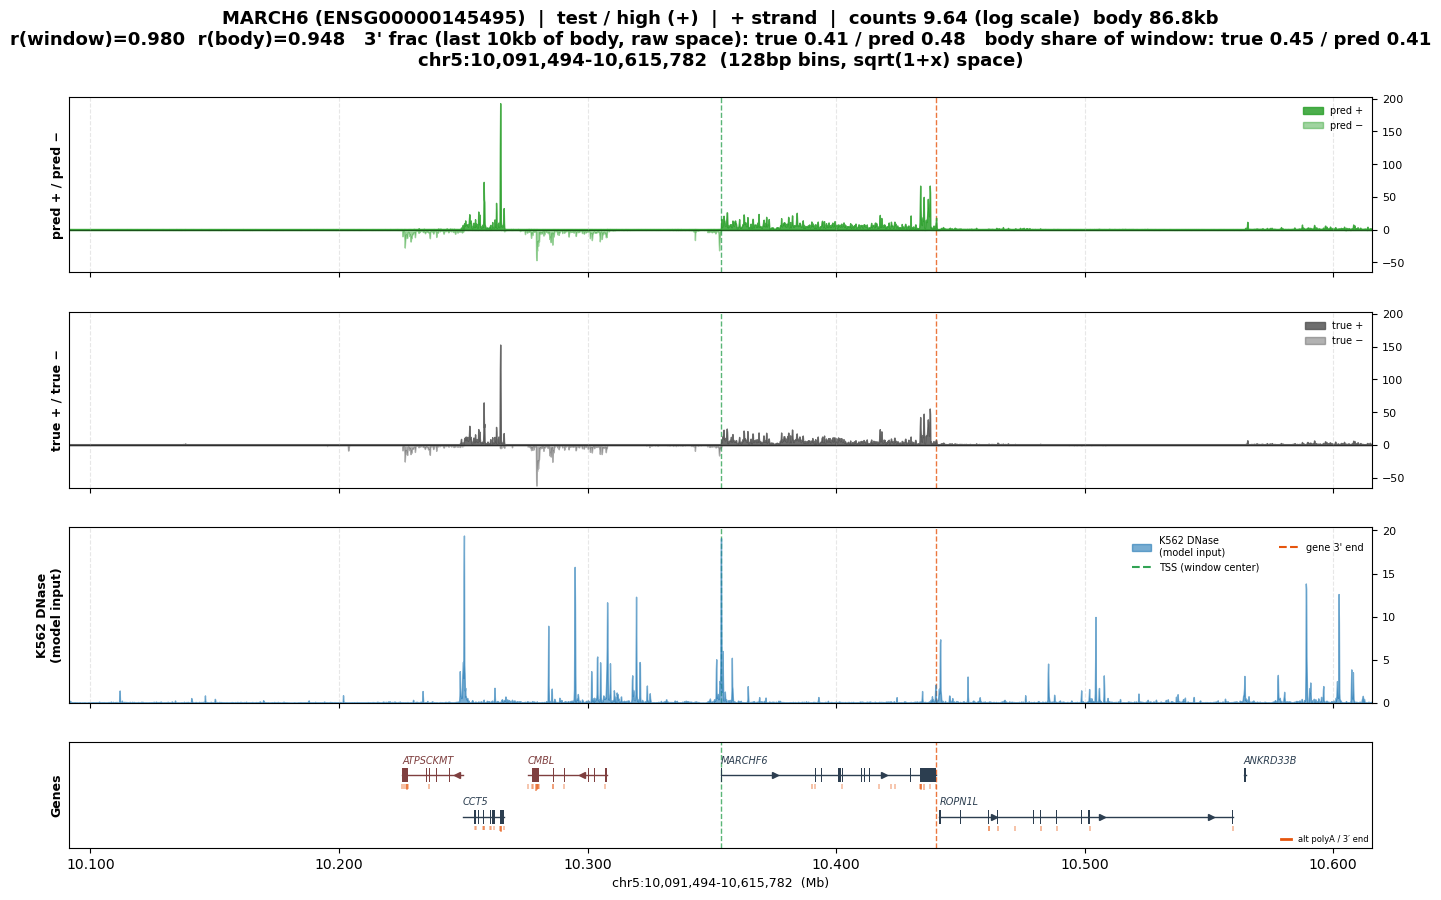

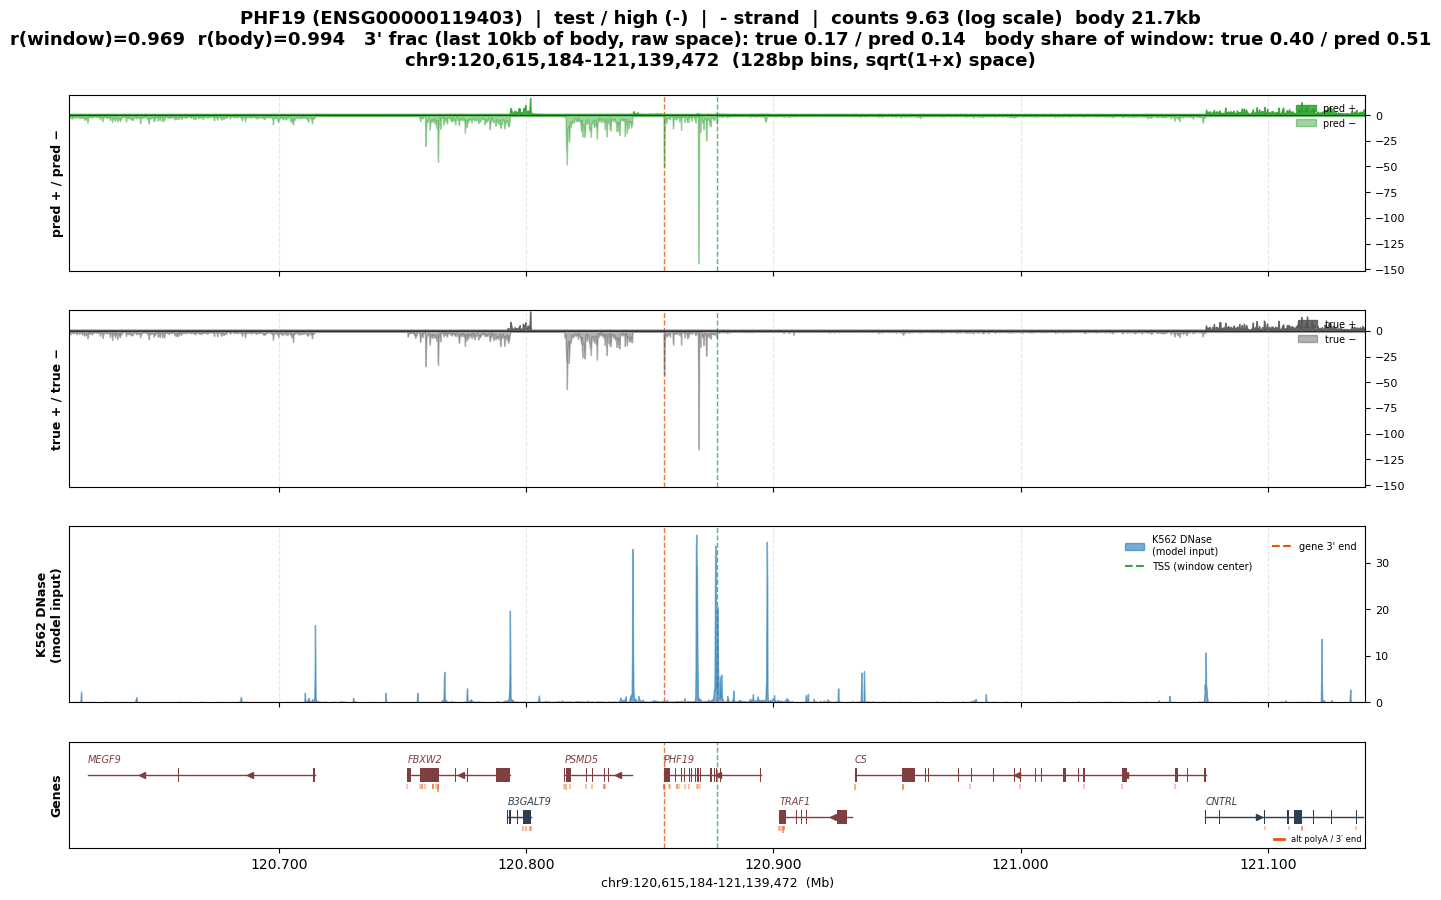

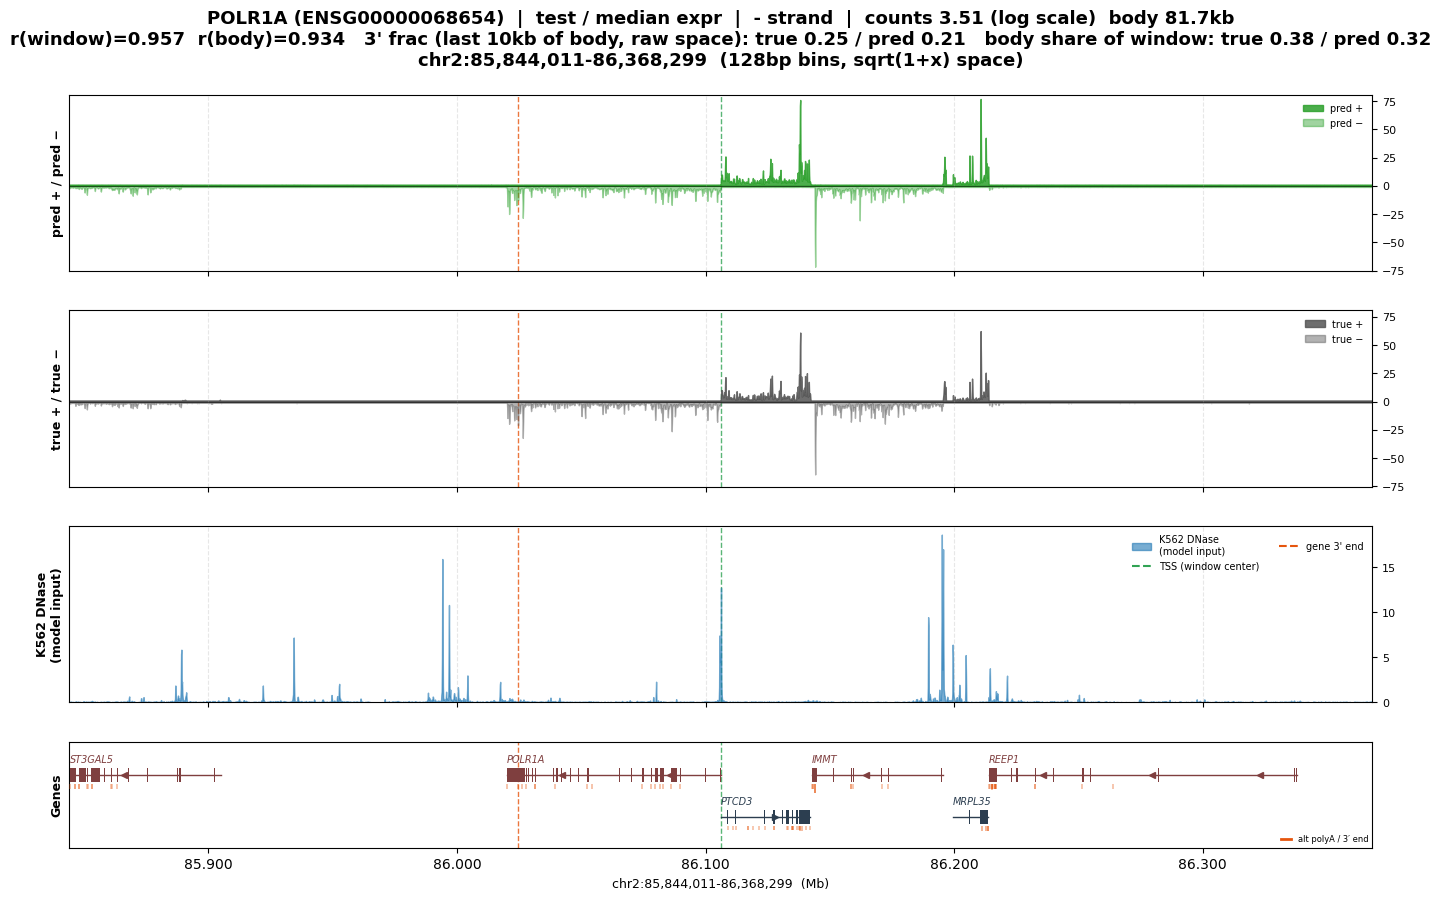

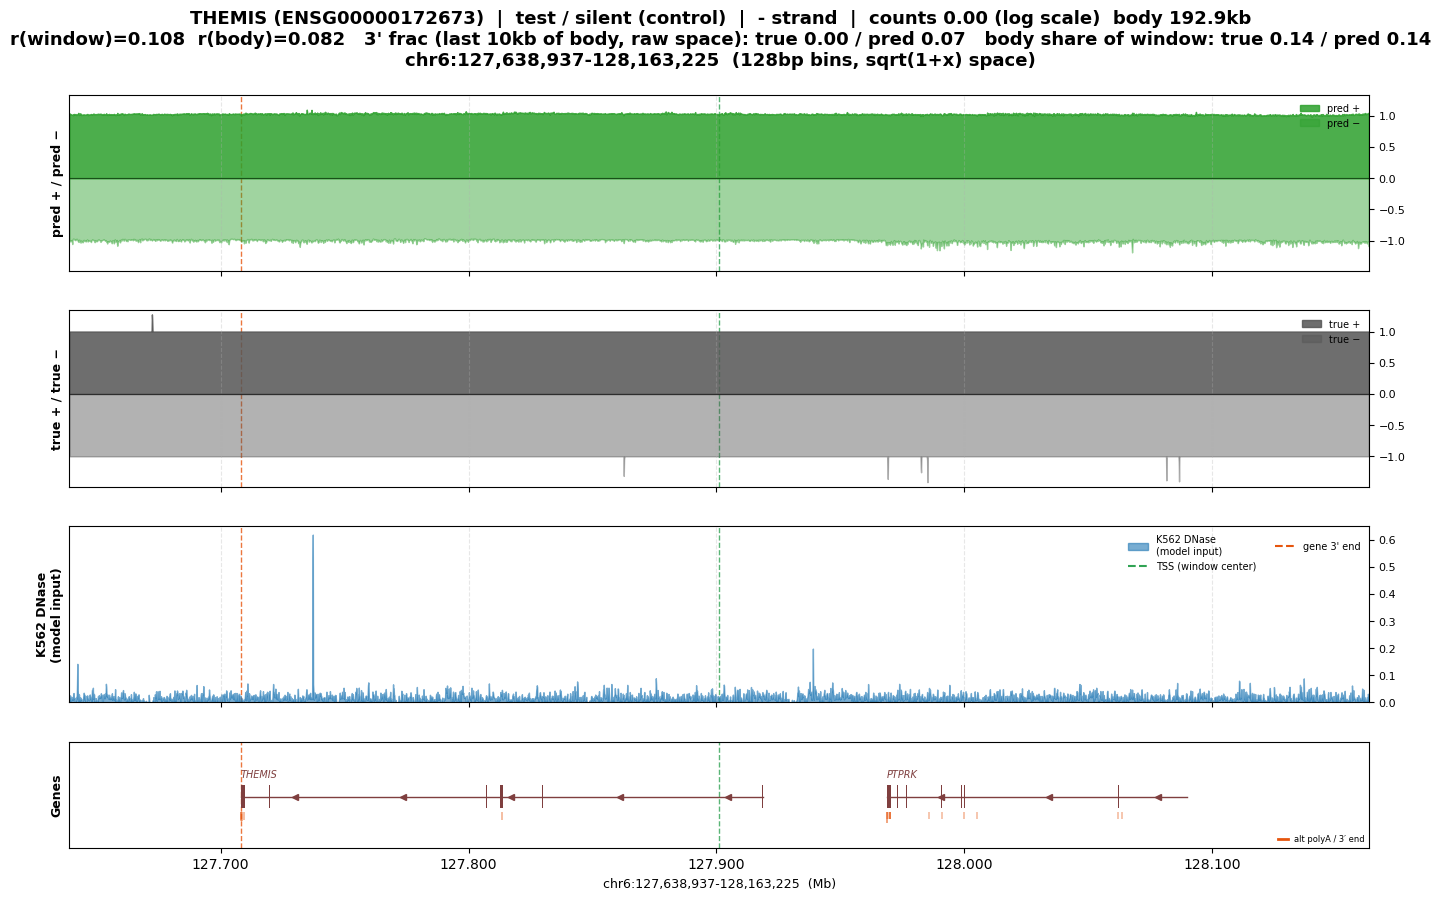

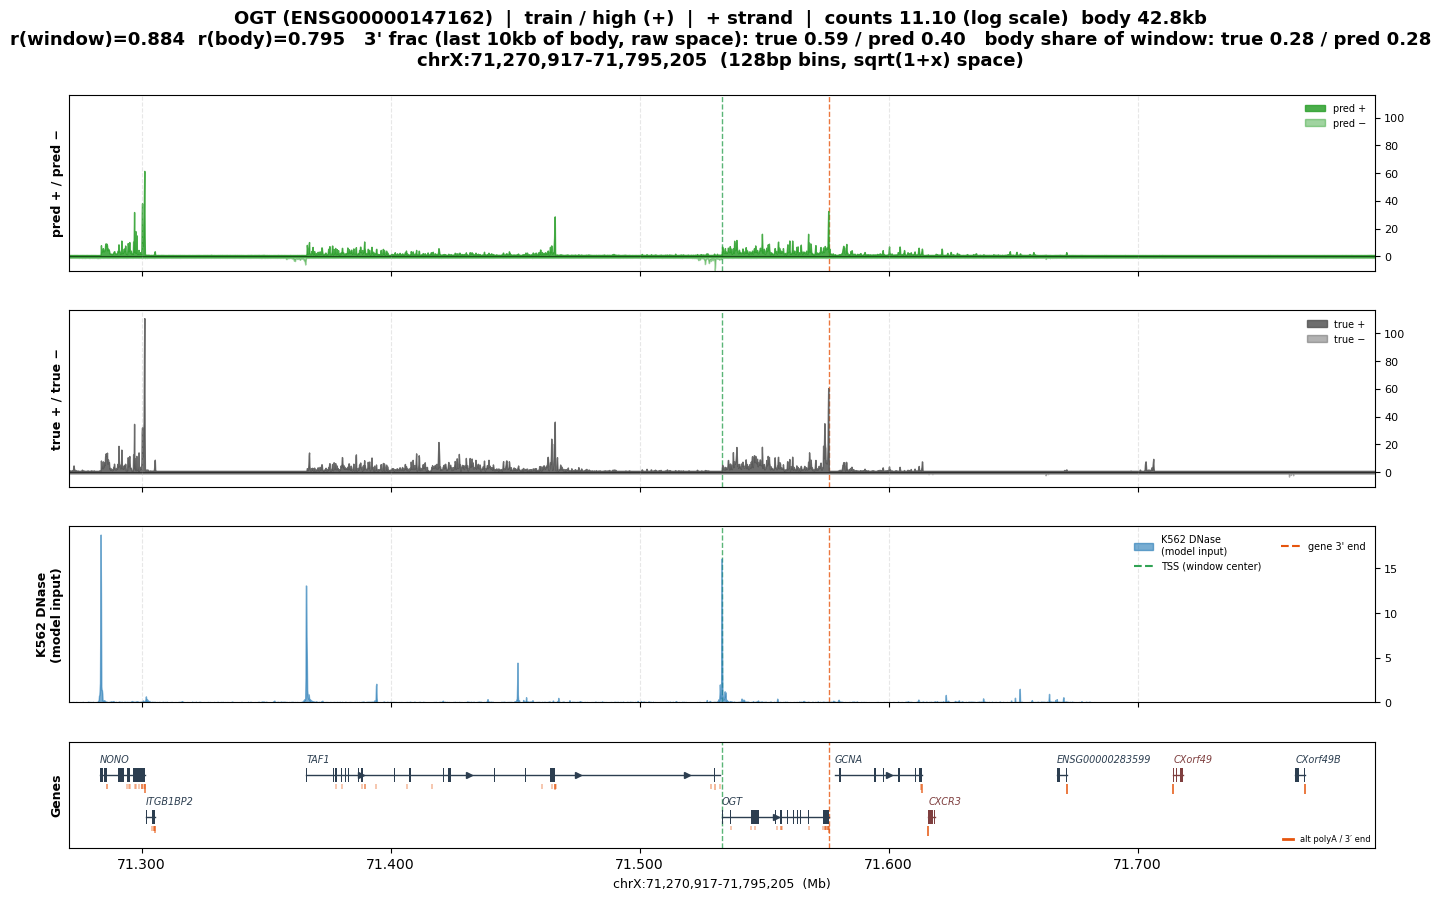

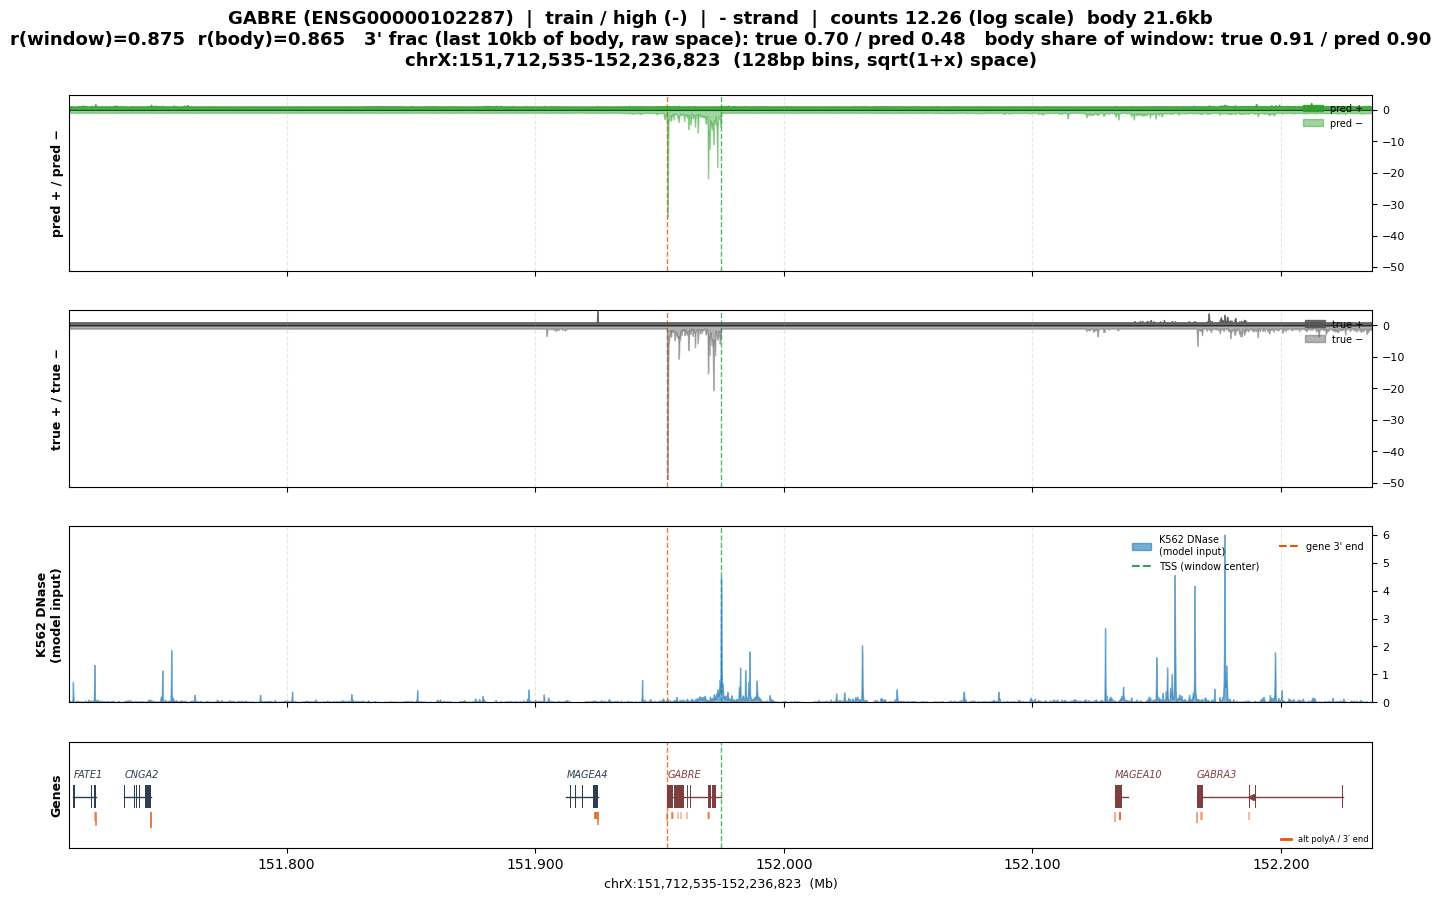

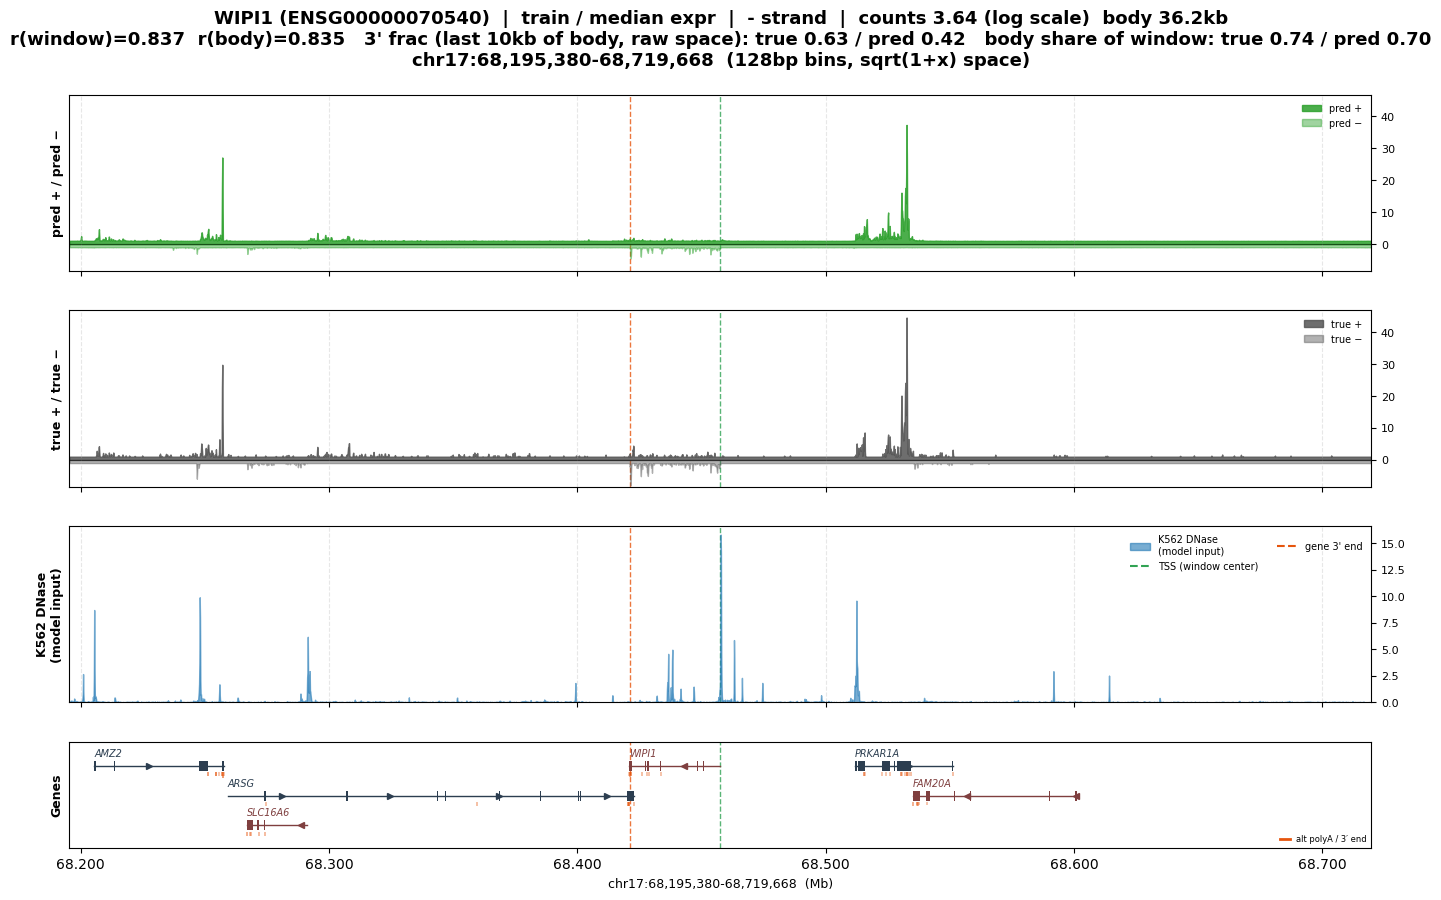

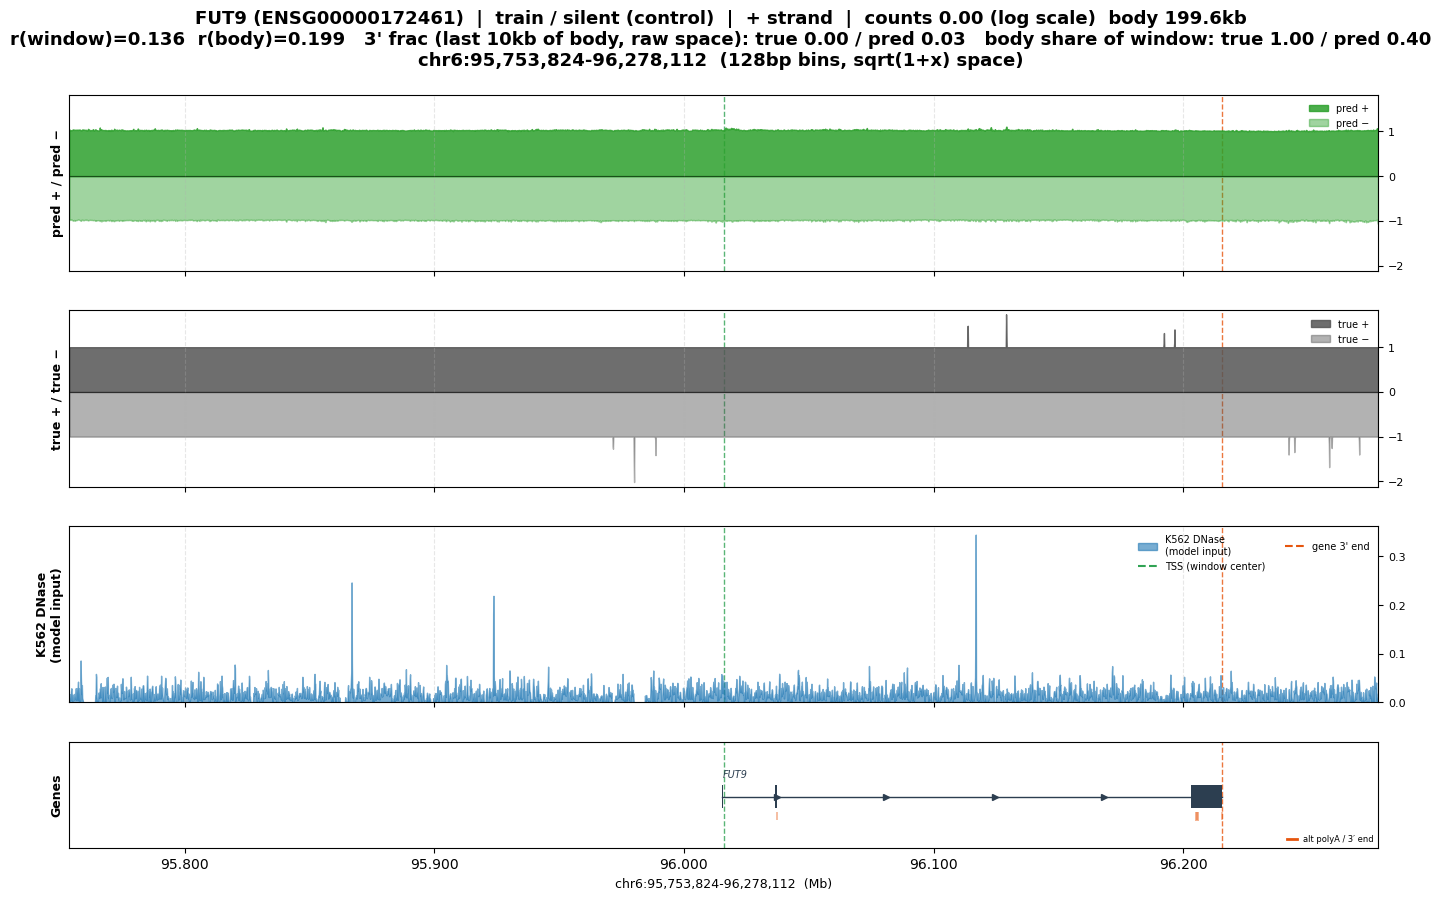

In [4]:
rows = []
for ensg, tag in SELECTED:
    rows.append(plot_example(ensg, tag))
summary = pd.DataFrame(rows)

## 5. Summary table

`r_window` / `r_body` are Pearson correlations of 128bp-binned prediction vs truth on the gene's own
strand, over the whole window and over the gene body. `true_3p_frac` / `pred_3p_frac` are the raw-space
fraction of the gene body's signal in its 3'-terminal 10kb: the closer the predicted fraction tracks
the true one, the more the model has actually learned the 3' pileup rather than smearing over the body.
`*_body_sum` are raw-space totals over the body, so a systematic magnitude bias shows up as a ratio.

In [5]:
cols = ['gene', 'tag', 'strand', 'counts', 'body_kb', 'r_window', 'r_body',
        'true_3p_frac', 'pred_3p_frac', 'true_body_frac_of_window', 'pred_body_frac_of_window',
        'true_body_sum', 'pred_body_sum']
with pd.option_context('display.width', 200, 'display.max_columns', None):
    print(summary[cols].to_string(index=False, float_format=lambda v: f'{v:,.3f}'))

expressed = summary[summary['counts'] > 0]
print(f"\nexpressed genes (n={len(expressed)}):  median r(window)={expressed['r_window'].median():.3f}"
      f"   median r(body)={expressed['r_body'].median():.3f}")
for split in ('test', 'train'):
    s = expressed[expressed['split'] == split]
    if len(s):
        print(f"  {split:<6} n={len(s)}  r(window)={s['r_window'].median():.3f}  "
              f"r(body)={s['r_body'].median():.3f}  "
              f"3' frac true {s['true_3p_frac'].median():.2f} / pred {s['pred_3p_frac'].median():.2f}")
print(f"\npredicted/true body-sum ratio (raw space), expressed genes: "
      f"{(expressed['pred_body_sum'] / expressed['true_body_sum']).median():.2f}x median")

  gene                      tag strand  counts  body_kb  r_window  r_body  true_3p_frac  pred_3p_frac  true_body_frac_of_window  pred_body_frac_of_window  true_body_sum  pred_body_sum
MARCH6          test / high (+)      +   9.636   86.750     0.980   0.948         0.414         0.480                     0.447                     0.415  7,043,008.915  9,118,210.021
 PHF19          test / high (-)      -   9.628   21.678     0.969   0.994         0.166         0.139                     0.404                     0.505  4,075,252.200  6,372,152.889
POLR1A       test / median expr      -   3.508   81.710     0.957   0.934         0.253         0.213                     0.376                     0.323  1,771,034.611  1,535,282.083
THEMIS  test / silent (control)      -   0.000  192.888     0.108   0.082         0.000         0.067                     0.139                     0.143        113.951      1,746.341
   OGT         train / high (+)      +  11.098   42.836     0.884   0.795       

# redoing with the new checkpoint

# evaluation_3prime — bp-resolution 3' RNA-seq profile predictions

Rerun of the section above on the **fixed** model: the same architecture and config retrained on the
rescaled RNA-seq target (`slurm_scripts/finetune_joint_k562_3prime.sh`, id 224,
`outputs/2026-08-13/16-16-44-251024`), checkpoint `07-val_loss=0.13696.ckpt` — the same checkpoint
`evals/evaluate_e2g_3prime.sh` now scores, so these figures and that E2G run describe the same
weights. Everything above this point is the unfixed model on `K562_rnaseq_stranded.npz`; the only
code differences here are `CKPT`, `RNA_NPZ`, and `raw()` (see below).

Four tracks per example, all on one shared genomic axis over the model's full 524288 bp input window:

| track | source |
|---|---|
| **Prediction** | decoder output, `(524288, 2)` = [plus, minus], softplus'd |
| **True 3' coverage** | `K562_rnaseq_stranded_fixed.npz`, the model's training target |
| **K562 DNase** | `acc[0]`, i.e. the accessibility the model was *given* as input |
| **Genes** | GENCODE v49, collapsed per gene, with alt-polyA ticks |

Conventions:

- **Mirrored strands.** Plus strand drawn upward, minus strand downward, on one axis per assay.
  This is fixed genomic orientation, *not* sense/antisense — the focal gene's strand is in each
  title, so for a `-` gene the gene's own signal is the downward half.
- **Binned to 128 bp** (mean) for display. The model predicts every base pair; 524288 raw points is
  unreadable, and 128 bp matches the bin size used in the `comparing_model*` notebooks.
- **Windows are TSS-centered**, via `dataset.expand_seqs(chrom, tss, tss)` exactly as
  `e2g_3prime.py` does, so local index 0 is always `tss - 262144`.
- **Both splits.** Test-split genes are held out; train-split genes were seen during training and are
  included as an upper bound on what the model can do, *not* as evidence of generalization. Split is
  labeled in every title.
- **Values are in `sqrt(1+x)-1` space**, which the model was trained in, so a no-signal base pair
  sits at 0.0. This is the one substantive difference from the unfixed npz above, which stored
  `sqrt(1+x)` with a 1.0 floor (`bigwig_to_npz.py:58`); the rescale was a −1 shift, verified on
  chr21 as identical shape, dtype and nonzero count with every value exactly 1.0 lower. Plots are in
  that space. The 3'-bias fractions in the summary are computed in **raw** space, which therefore
  needs `clip((pred + 1)**2 - 1, 0, None)` here rather than the `clip(pred**2 - 1, 0, None)` used
  above — the unshifted form would clip 41% of nonzero base pairs to zero. Correlations
  (`r_window`, `r_body`) are unaffected either way, being shift-invariant.

## 1. Setup

`Evals` comes from `e2g_3prime.py` unchanged. The one thing that has to be undone is its
`dataset_args['additional_tracks'] = None`: E2G only ever reads predictions, but here the true
coverage *is* the point. `Evals` applies `**dataset_overrides` after that line, so passing
`additional_tracks=RNA_NPZ` restores it and `__getitem__` returns a 3-element `outputs2` whose last
entry is the `(524288, 2)` bp-resolution target.

`load_data=False` keeps the genome / DNase / RNA npz files lazy. That costs a whole-chromosome
decompression per npz per example (a few seconds), which is the right trade for ~8 examples — the
`--load_data` path in the sbatch exists for 12k forward passes, and would want ~150 GB.

In [1]:
import json
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

sys.path.insert(0, '/data1/lesliec/sarthak/caduceus')
from evals.plotting_utils import Track, GeneAnnotation, plot_tracks
from evals.e2g_3prime import Evals, INPUT_LEN, HALF, STRAND_ROW

# same checkpoint as evals/evaluate_e2g_3prime.sh, now the FIXED run (id 224). Epoch 7, not the
# val-loss minimum (epoch 2, 0.12826): this run overfits almost immediately -- train loss falls
# monotonically while val flattens, so the generalization gap grows from 0.10 at ep 2 to 0.20 at
# ep 7 -- but ep 7's 0.13696 is 0.009 off the minimum against a val sd of ~0.021, i.e. within
# noise, with 3.5x more training. val_loss is NOT comparable to the unfixed run's ~0.85: the
# poisson loss is computed directly against the target, whose scale changed.
CKPT = ('/data1/lesliec/sarthak/caduceus/outputs/2026-08-13/16-16-44-251024/checkpoints/07-val_loss=0.13696.ckpt')

RNA_NPZ    = '/data1/lesliec/sarthak/data/DE_danwei/K562_gex/K562_rnaseq_stranded_fixed.npz'
GENE_JSON  = '/data1/lesliec/sarthak/data/DE_danwei/k562_bulk_rna_info.json'
BOUNDS_BED = '/data1/deyk/extras/CollapsedGeneBounds.hg38.bed'

BIN = 128                       # display bin size (bp); model itself is bp-resolution
THREE_PRIME_LEN = 10_000        # 3'-terminal window for the bias fraction, as in e2g_3prime.py

# gene-body length bounds for example selection: long enough that a 3' bias is visible at 128bp,
# short enough to sit inside the 524kb window with flanks
MIN_BODY, MAX_BODY = 20_000, 200_000

PRED_COLOR, TRUE_COLOR, DNASE_COLOR = '#2ca02c', '#555555', '#1f77b4'
TSS_COLOR, PA_COLOR = '#31a354', '#e6550d'

evals = Evals(CKPT, split='test', load_data=False, additional_tracks=RNA_NPZ)
print('device:', evals.device)

# sanity: the dataset must now hand back the RNA target as the last element of outputs2
_probe = evals.dataset[0]
print('outputs1:', [tuple(t.shape) for t in _probe[0]])
print('outputs2:', [tuple(t.shape) for t in _probe[1]])
assert len(_probe[1]) == 3, 'additional_tracks override did not take: no RNA target returned'
assert _probe[1][-1].shape == (INPUT_LEN, 2), f'unexpected target shape {_probe[1][-1].shape}'
del _probe

ann = GeneAnnotation()
print('annotation rows:', len(ann.df))

E2G for bp-resolution 3prime RNA profile model
Overriding additional_tracks with /data1/lesliec/sarthak/data/DE_danwei/K562_gex/K562_rnaseq_stranded_fixed.npz
JointMaskingEncoder: d_model=256, celltypes=None, d_input1=6, d_input2=None, joint=False, kernel_size=15, combine=True, acc_type=continuous
Using norm: seq=<class 'torch.nn.modules.linear.Identity'>, rest=<class 'torch.nn.modules.linear.Identity'>
Using activation: <class 'torch.nn.modules.activation.ReLU'>
device: cuda
outputs1: [(6, 524288), (2, 524288)]
outputs2: [(524288, 6), (524288, 2), (524288, 2)]
annotation rows: 3222714


## 2. Gene table and example selection

`k562_bulk_rna_info.json` supplies TSS / strand / chrom / split (the same file the model's gene
splits were defined against) plus `counts`, the bulk K562 expression used here only to rank
candidates. Gene bodies come from `CollapsedGeneBounds.hg38.bed`, outermost span per Ensembl ID —
identical to `e2g_3prime.py`'s `load_benchmark`.

Selection is deterministic, no sampling: per split, the top-expressed gene on each strand (so both
mirror directions are exercised), the gene nearest the median expression of expressed genes, and one
silent gene (`counts == 0`, longest eligible body) as a negative control — the model should predict
near-baseline there, and a confident profile over a silent gene is a failure mode worth seeing.

In [2]:
info = json.load(open(GENE_JSON))
genes = pd.DataFrame(info).T
genes.index.name = 'ensg_id'
genes['tss'] = genes['tss'].astype(int)
genes['counts'] = genes['counts'].astype(float)

bounds = pd.read_csv(BOUNDS_BED, sep='\t').groupby('Ensembl_ID').agg(
    gene_name=('name', 'first'), gene_start=('start', 'min'), gene_end=('end', 'max'),
    gene_strand=('strand', 'first'))
genes = genes.join(bounds)
genes['body_len'] = genes['gene_end'] - genes['gene_start']

# only chromosomes present in BOTH npz files, else __getitem__ raises a KeyError
chroms = set(evals.dataset.additional_tracks.files) & set(evals.dataset.data.files)

eligible = (
    genes['gene_start'].notna()
    & genes['chrom'].isin(chroms)
    & genes['body_len'].between(MIN_BODY, MAX_BODY)
    & (genes['tss'] >= genes['gene_start']) & (genes['tss'] <= genes['gene_end'])
    # whole body inside the TSS-centered window, so body / 3'-terminal sums are never truncated
    & (genes['gene_start'] >= genes['tss'] - HALF) & (genes['gene_end'] <= genes['tss'] + HALF)
)
print(f'{eligible.sum()} of {len(genes)} genes eligible')
print(genes.loc[eligible, 'split'].value_counts().to_string())


def pick(split):
    '''One high-expression gene per strand, one median-expression gene, one silent gene.'''
    sub = genes[eligible & (genes['split'] == split)]
    expressed = sub[sub['counts'] > 0].sort_values('counts', ascending=False)
    picks = []
    for strand in ('+', '-'):
        s = expressed[expressed['strand'] == strand]
        if len(s):
            picks.append((s.index[0], f'{split} / high ({strand})'))
    med = expressed['counts'].median()
    picks.append(((expressed['counts'] - med).abs().idxmin(), f'{split} / median expr'))
    silent = sub[sub['counts'] == 0]
    if len(silent):
        picks.append((silent['body_len'].idxmax(), f'{split} / silent (control)'))
    return picks


SELECTED, seen = [], set()
for split in ('test', 'train'):
    for ensg, tag in pick(split):
        if ensg not in seen:
            seen.add(ensg)
            SELECTED.append((ensg, tag))

print(f'\n{len(SELECTED)} examples:')
for ensg, tag in SELECTED:
    g = genes.loc[ensg]
    print(f'  {g.gene_name:<12} {ensg}  {tag:<26} {g.chrom}:{g.gene_start:,}-{g.gene_end:,} '
          f'({g.strand})  body {g.body_len/1e3:.1f}kb  counts {g.counts:.2f}')

8868 of 18628 genes eligible
split
train    6902
val      1064
test      902

8 examples:
  MARCH6       ENSG00000145495  test / high (+)            chr5:10,353,638-10,440,388 (+)  body 86.8kb  counts 9.64
  PHF19        ENSG00000119403  test / high (-)            chr9:120,855,650-120,877,328 (-)  body 21.7kb  counts 9.63
  POLR1A       ENSG00000068654  test / median expr         chr2:86,024,445-86,106,155 (-)  body 81.7kb  counts 3.51
  THEMIS       ENSG00000172673  test / silent (control)    chr6:127,708,193-127,901,081 (-)  body 192.9kb  counts 0.00
  OGT          ENSG00000147162  train / high (+)           chrX:71,533,061-71,575,897 (+)  body 42.8kb  counts 11.10
  GABRE        ENSG00000102287  train / high (-)           chrX:151,953,123-151,974,679 (-)  body 21.6kb  counts 12.26
  WIPI1        ENSG00000070540  train / median expr        chr17:68,421,280-68,457,524 (-)  body 36.2kb  counts 3.64
  FUT9         ENSG00000172461  train / silent (control)   chr6:96,015,968-96,215,612 (+

## 3. Forward pass, binning and the per-example figure

One data load + one forward pass per gene. The prediction is `(524288, 2)`; column 0 is the plus
strand and column 1 the minus strand, matching `STRAND_ROW` and the row order of
`K562_rnaseq_stranded_fixed.npz` (whose deliberate reverse/forward bigwig swap is documented in
`bigwig_to_npz.py:7-8`).

The prediction and truth axes are given the **same symmetric y-limits**, so their heights are
directly comparable; DNase keeps its own scale (different assay). `plot_tracks`'s dashed truth-max
reference is not used — with mirrored strands an explicit shared `ylim` is the honest version.

In [3]:
def fetch(chrom, tss):
    '''-> pred (INPUT_LEN, 2), true (INPUT_LEN, 2), dnase (INPUT_LEN,), all sqrt(1+x)-1 space.'''
    idx = evals.dataset.expand_seqs(chrom, int(tss), int(tss))
    (seq, acc), extra = evals.dataset[idx]
    true = extra[-1].numpy()          # (INPUT_LEN, 2) bp-resolution target
    dnase = acc[0].numpy()            # row 0 = continuous DNase, row 1 = the mask channel
    pred = evals.predict(seq.unsqueeze(0), acc.unsqueeze(0))[0]
    return pred, true, dnase


def rebin(x, bin_size=BIN):
    '''Mean-pool the leading (bp) axis. Works for (L,) and (L, C).'''
    return x.reshape(-1, bin_size, *x.shape[1:]).mean(axis=1)


def raw(x):
    '''Undo sqrt(1+x)-1 so the 0.0-per-bp baseline drops out of sums.

    K562_rnaseq_stranded_fixed.npz stores sqrt(1+x)-1, one less than the unfixed npz's sqrt(1+x)
    (verified on chr21: identical shape/dtype/nonzero count, every value exactly 1.0 lower, modal
    value 0.0 vs 1.0). The model was trained against that target, so predictions are in the same
    shifted space. Using the unshifted x**2-1 here would send every stored value below 1.0 negative
    and clip it to zero -- 41% of nonzero base pairs and 28% of total raw signal on chr21, biased
    toward exactly the low-coverage positions. Correlations are unaffected (Pearson is invariant to
    a constant shift, applied to pred and truth alike); only the raw-space sums and fractions are.
    '''
    return np.clip((x.astype(np.float64) + 1.0) ** 2 - 1.0, 0, None)


def summarize(pred, true, g):
    '''Correlations on the gene's own strand, plus how 3'-skewed each profile is.'''
    seq_start = int(g.tss) - HALF
    s = STRAND_ROW[g.strand]
    body = slice(int(g.gene_start) - seq_start, int(g.gene_end) - seq_start)
    if g.strand == '+':
        tp = slice(max(body.start, body.stop - THREE_PRIME_LEN), body.stop)
    else:
        tp = slice(body.start, min(body.stop, body.start + THREE_PRIME_LEN))

    pb, tb = rebin(pred)[:, s], rebin(true)[:, s]
    out = {'r_window': pearsonr(pb, tb)[0]}
    b0, b1 = body.start // BIN, -(-body.stop // BIN)
    out['r_body'] = (pearsonr(pb[b0:b1], tb[b0:b1])[0]
                     if tb[b0:b1].std() > 1e-8 and pb[b0:b1].std() > 1e-8 else np.nan)

    # fraction of the gene's raw-space signal falling in its 3'-terminal 10kb. A 3' assay should
    # concentrate there; body_frac_of_window says how much of the window's signal is this gene at all.
    for name, arr in (('true', true), ('pred', pred)):
        r = raw(arr[:, s])
        body_sum, win_sum = r[body].sum(), r.sum()
        out[f'{name}_3p_frac'] = r[tp].sum() / body_sum if body_sum > 0 else np.nan
        out[f'{name}_body_frac_of_window'] = body_sum / win_sum if win_sum > 0 else np.nan
    out['true_body_sum'] = raw(true[:, s])[body].sum()
    out['pred_body_sum'] = raw(pred[:, s])[body].sum()
    return out


def plot_example(ensg, tag):
    g = genes.loc[ensg]
    chrom, tss, strand = g.chrom, int(g.tss), g.strand
    seq_start = tss - HALF
    pred, true, dnase = fetch(chrom, tss)
    st = summarize(pred, true, g)

    pb, tb, db = rebin(pred), rebin(true), rebin(dnase)
    # y-limits shared by the prediction and truth axes, so the two axes' heights are directly
    # comparable. Scaled per direction rather than symmetrically: one strand is usually near
    # baseline, and a symmetric mirror would spend half the axis on it.
    ylim = (-1.05 * max(pb[:, 1].max(), tb[:, 1].max()),
            1.05 * max(pb[:, 0].max(), tb[:, 0].max()))
    common = dict(chrom=chrom, start=seq_start, bin_size=BIN)

    tracks = [
        Track(pb[:, 0], name='pred +', color=PRED_COLOR, style='fill', alpha=0.85,
              ylim=ylim, overlay_group=0, **common),
        Track(-pb[:, 1], name='pred −', color=PRED_COLOR, style='fill', alpha=0.45,
              overlay_group=0, **common),
        Track(tb[:, 0], name='true +', color=TRUE_COLOR, style='fill', alpha=0.85,
              ylim=ylim, overlay_group=1, **common),
        Track(-tb[:, 1], name='true −', color=TRUE_COLOR, style='fill', alpha=0.45,
              overlay_group=1, **common),
        Track(db, name='K562 DNase\n(model input)', color=DNASE_COLOR, style='fill', alpha=0.6,
              **common),
    ]

    polya = int(g.gene_end) if strand == '+' else int(g.gene_start)
    title = (f'{g.gene_name} ({ensg})  |  {tag}  |  {strand} strand  |  '
             f'counts {g.counts:.2f} (log scale)  body {g.body_len/1e3:.1f}kb\n'
             f"r(window)={st['r_window']:.3f}  r(body)={st['r_body']:.3f}   "
             f"3' frac (last {THREE_PRIME_LEN/1e3:.0f}kb of body, raw space): "
             f"true {st['true_3p_frac']:.2f} / pred {st['pred_3p_frac']:.2f}   "
             f"body share of window: true {st['true_body_frac_of_window']:.2f} / "
             f"pred {st['pred_body_frac_of_window']:.2f}\n"
             f'{chrom}:{seq_start:,}-{seq_start + INPUT_LEN:,}  ({BIN}bp bins, sqrt(1+x)-1 space)')

    fig, axes = plot_tracks(tracks, genes=ann, region=(chrom, seq_start, seq_start + INPUT_LEN),
                            collapse_genes=True, splice_marks='polya', title=title,
                            figsize=(14, 9))

    # TSS / polyA guides on every axis, and a zero line on the two mirrored axes
    for i, ax in enumerate(axes):
        ax.axvline(tss, color=TSS_COLOR, ls='--', lw=1.0, alpha=0.8, zorder=0)
        ax.axvline(polya, color=PA_COLOR, ls='--', lw=1.0, alpha=0.8, zorder=0)
        if i < 2:
            ax.axhline(0, color='black', lw=0.8, alpha=0.5)
    # guide legend goes on the DNase axis: plot_tracks already legends the two mirrored axes
    # (one entry per strand), and a second legend() call there would replace it.
    axes[2].plot([], [], color=TSS_COLOR, ls='--', label='TSS (window center)')
    axes[2].plot([], [], color=PA_COLOR, ls='--', label="gene 3' end")
    axes[2].legend(fontsize=7, loc='upper right', frameon=False, ncol=2)

    plt.show()
    return dict(gene=g.gene_name, ensg=ensg, tag=tag, split=g.split, strand=strand,
                counts=g.counts, body_kb=g.body_len / 1e3, **st)

## 4. The figures

One figure per selected gene. Expect, for a working 3' model: signal concentrated at the gene's 3'
end on the gene's own strand (upward for a `+` gene, downward for a `-` gene), the *other* strand
near the 1.0 baseline, and near-baseline everywhere for the silent control. The TSS guide is where a
5'/CAGE model would peak instead — signal there is a sign the model is smearing across the gene
rather than reproducing the 3' bias.

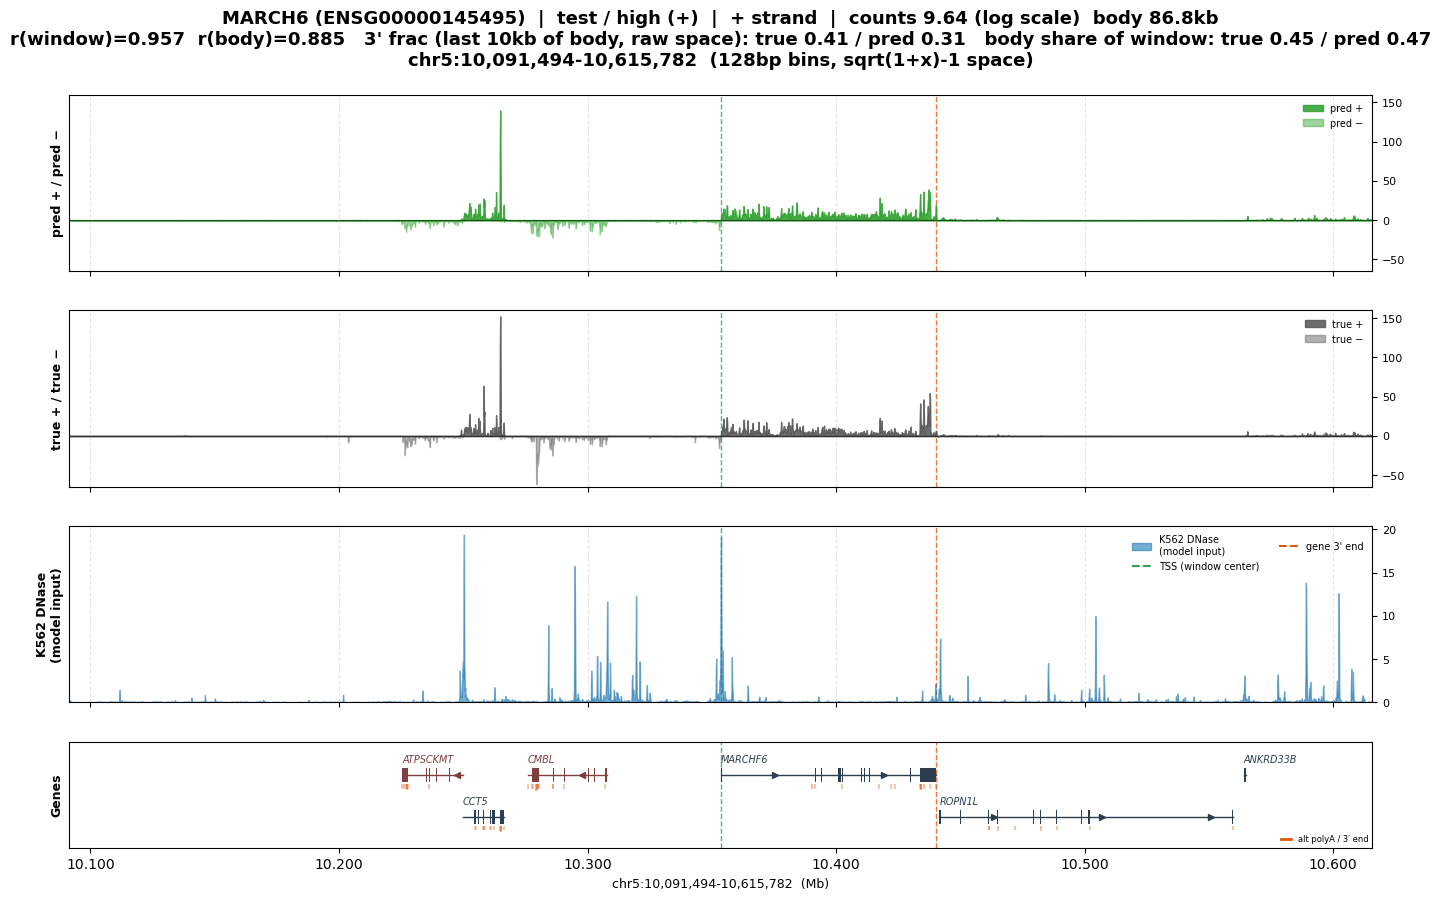

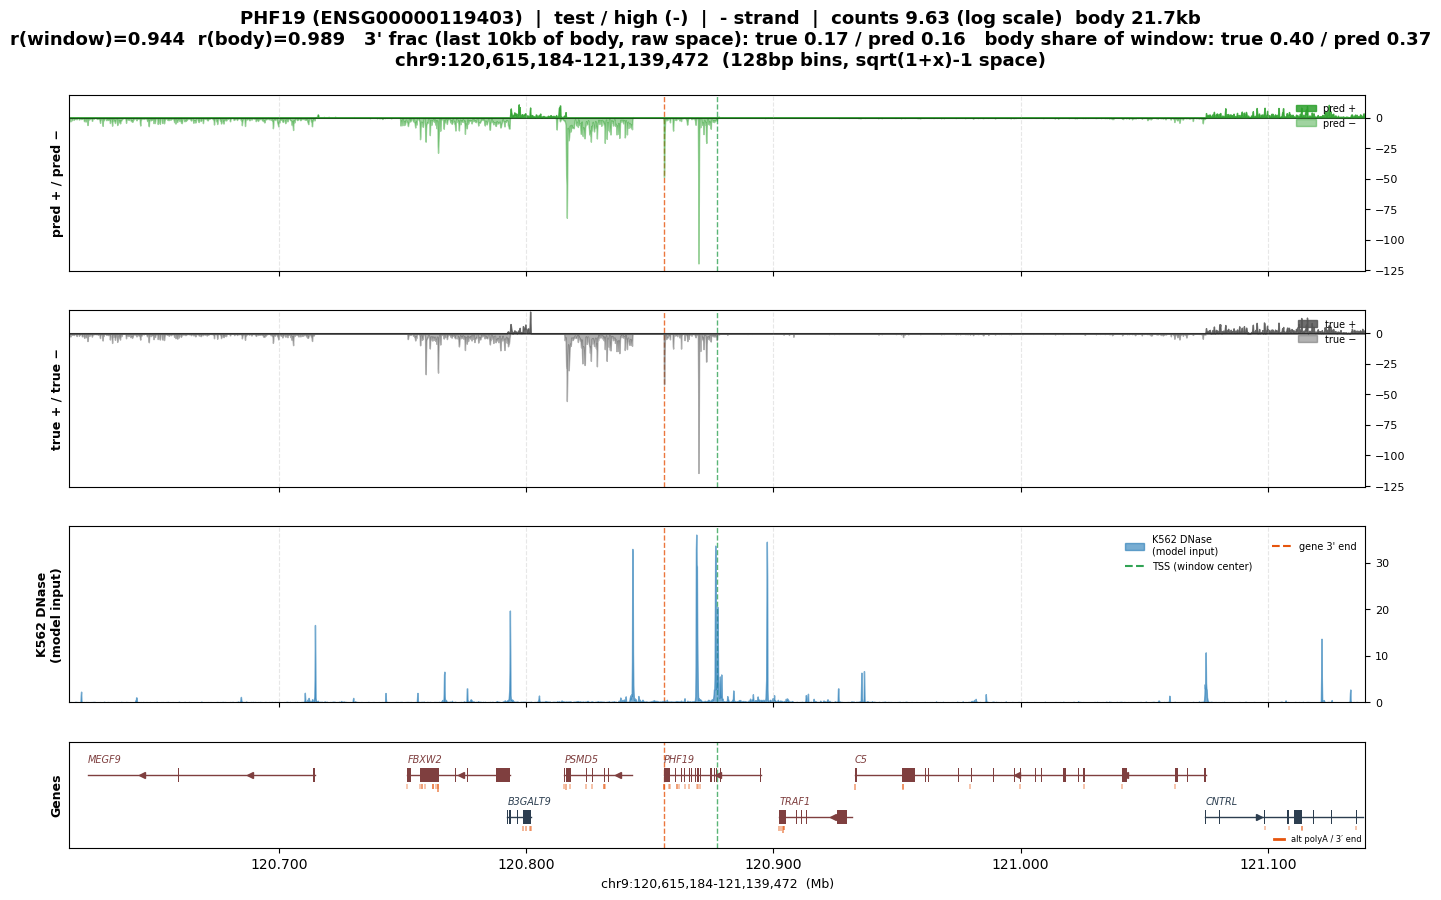

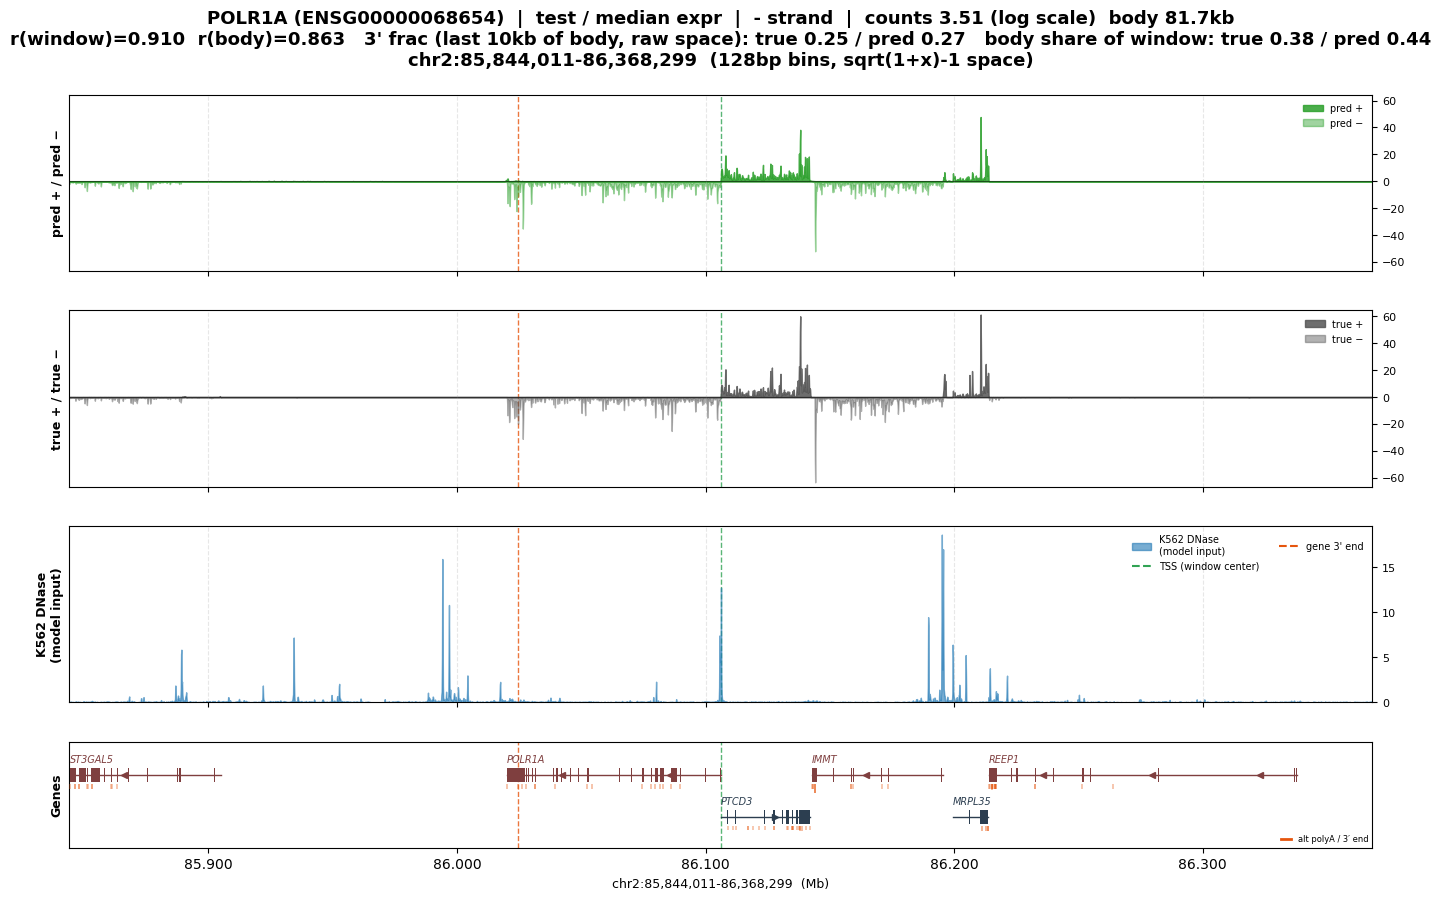

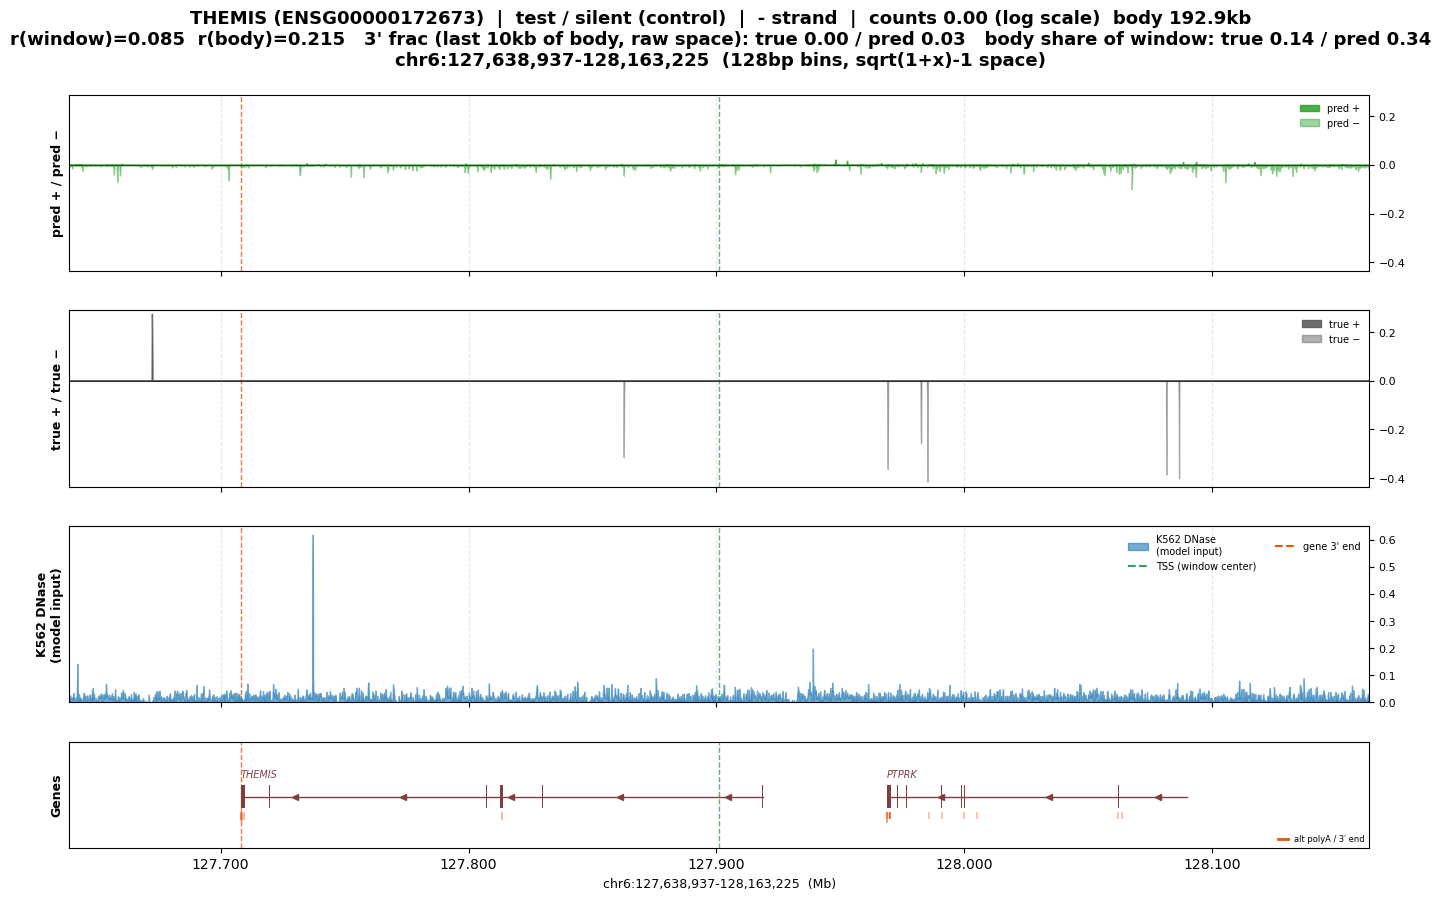

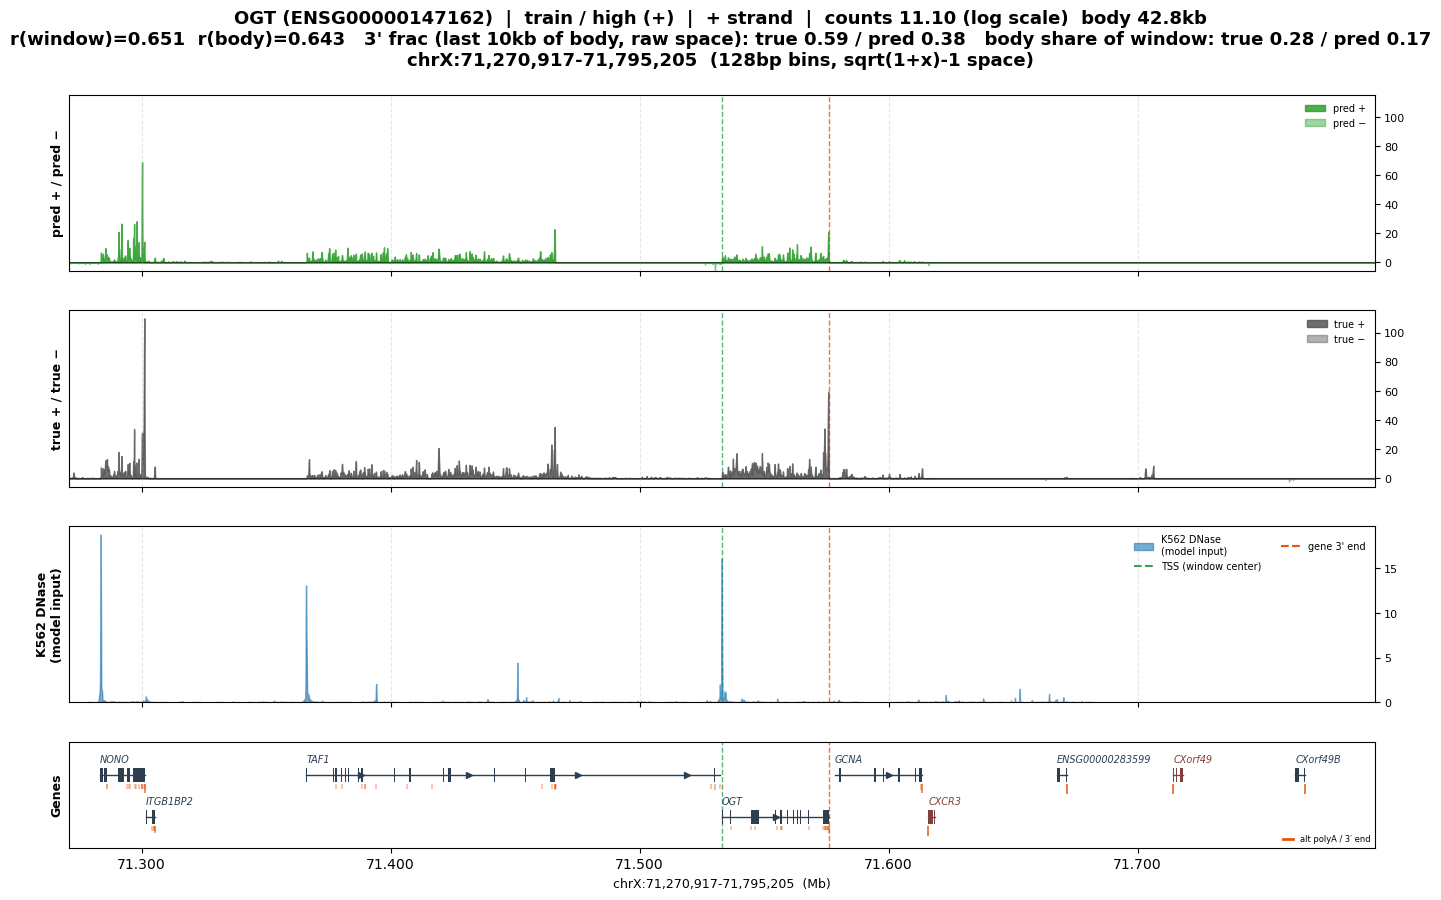

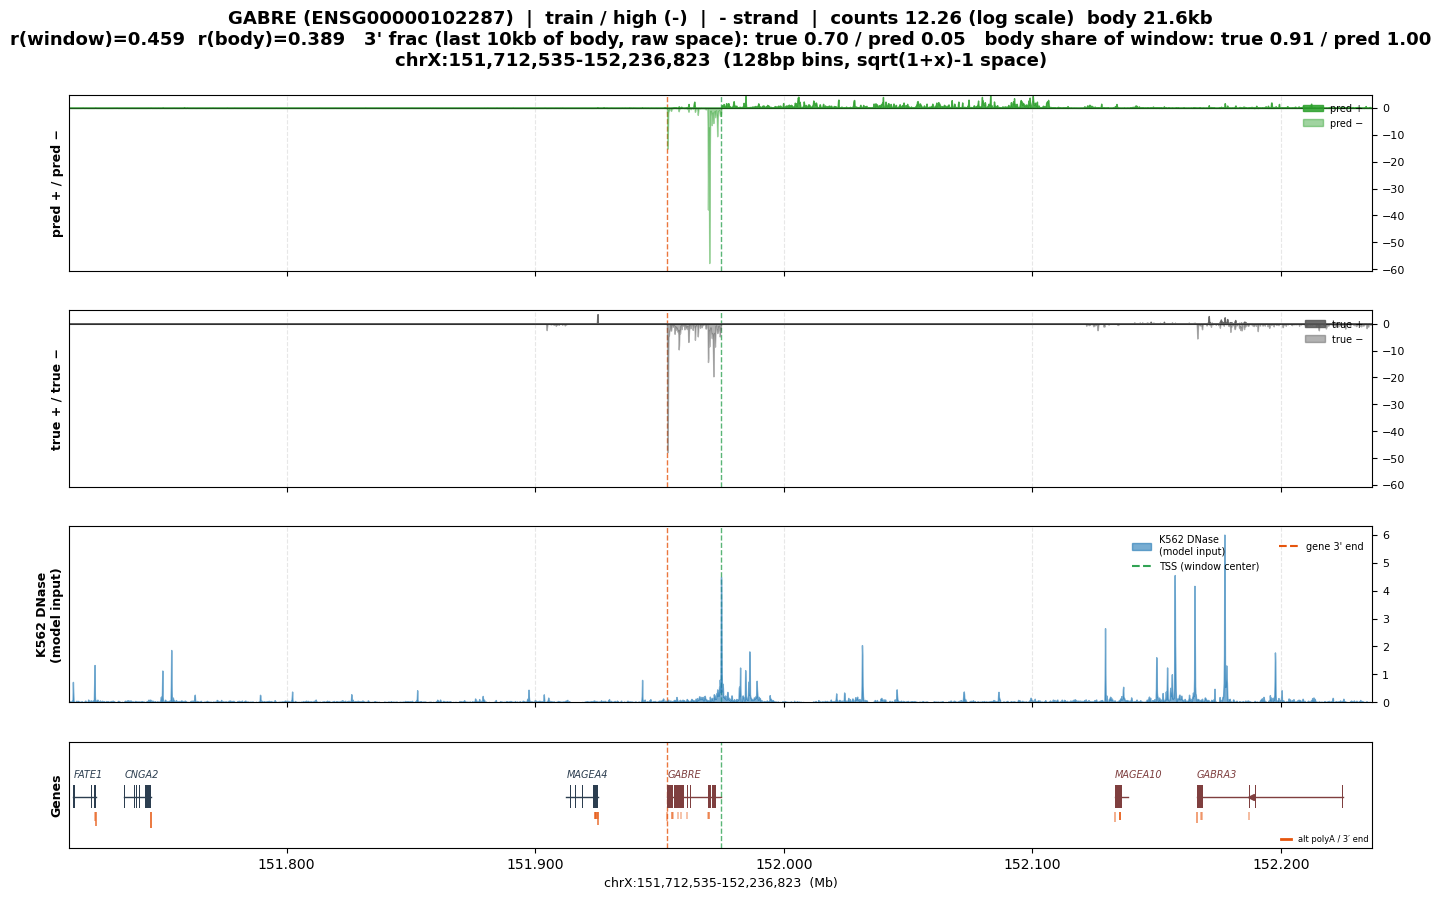

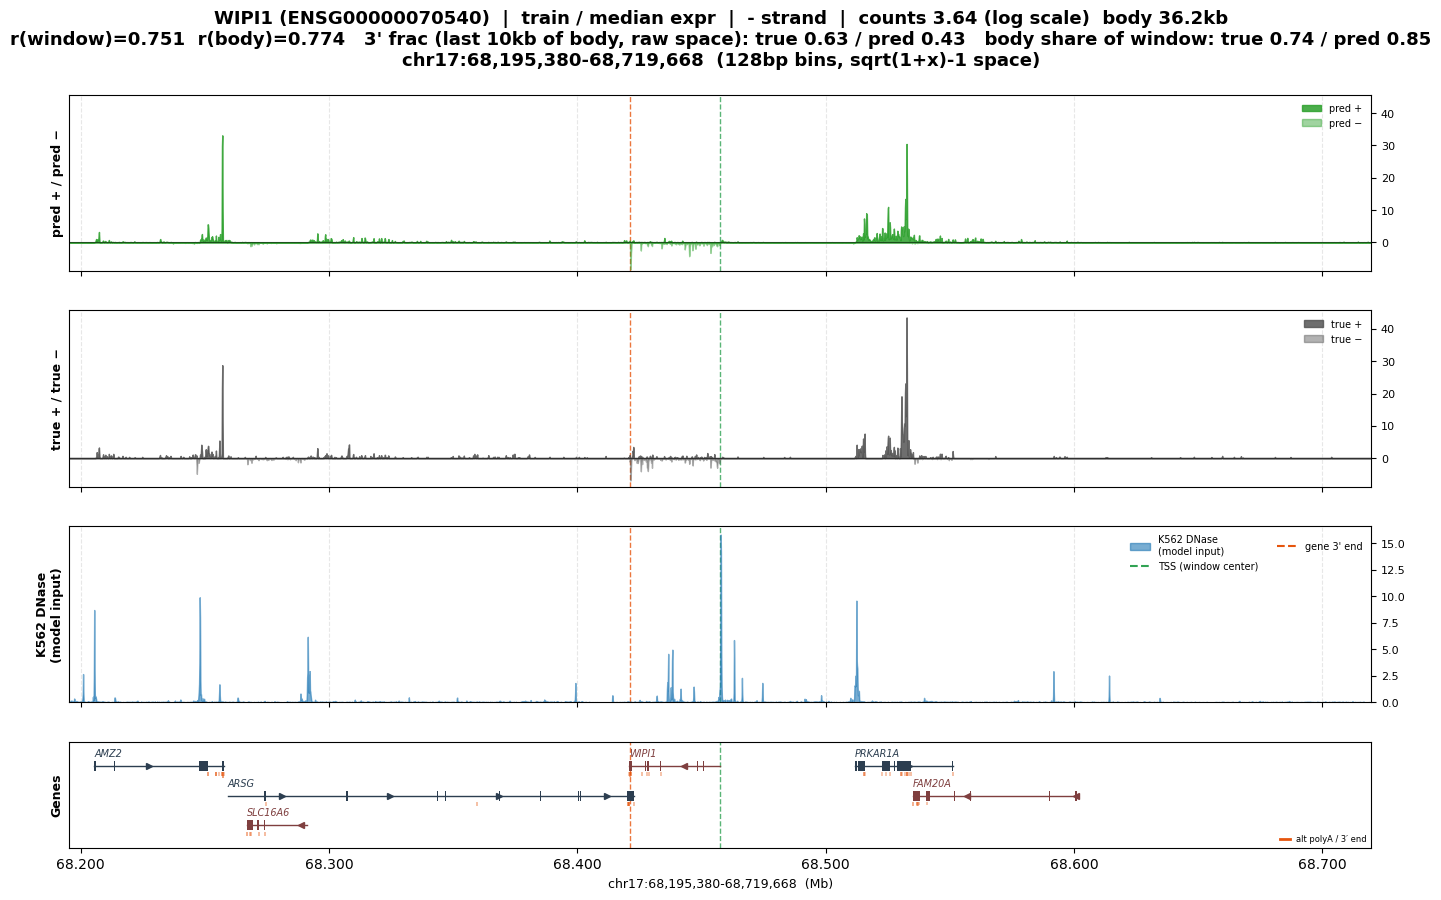

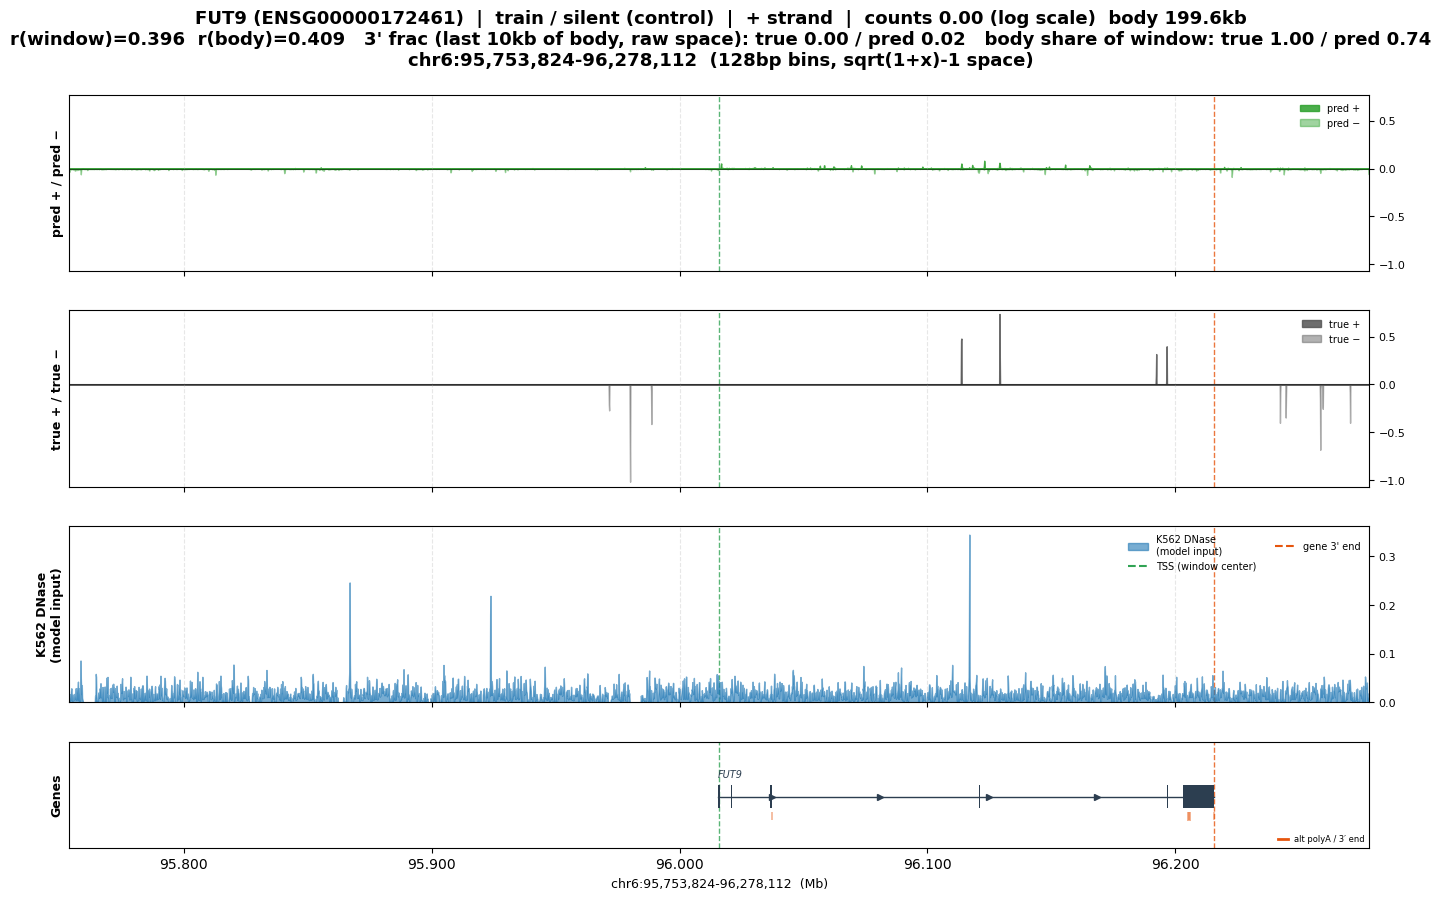

In [4]:
rows = []
for ensg, tag in SELECTED:
    rows.append(plot_example(ensg, tag))
summary = pd.DataFrame(rows)

## 5. Summary table

`r_window` / `r_body` are Pearson correlations of 128bp-binned prediction vs truth on the gene's own
strand, over the whole window and over the gene body. `true_3p_frac` / `pred_3p_frac` are the raw-space
fraction of the gene body's signal in its 3'-terminal 10kb: the closer the predicted fraction tracks
the true one, the more the model has actually learned the 3' pileup rather than smearing over the body.
`*_body_sum` are raw-space totals over the body, so a systematic magnitude bias shows up as a ratio.

In [5]:
cols = ['gene', 'tag', 'strand', 'counts', 'body_kb', 'r_window', 'r_body',
        'true_3p_frac', 'pred_3p_frac', 'true_body_frac_of_window', 'pred_body_frac_of_window',
        'true_body_sum', 'pred_body_sum']
with pd.option_context('display.width', 200, 'display.max_columns', None):
    print(summary[cols].to_string(index=False, float_format=lambda v: f'{v:,.3f}'))

expressed = summary[summary['counts'] > 0]
print(f"\nexpressed genes (n={len(expressed)}):  median r(window)={expressed['r_window'].median():.3f}"
      f"   median r(body)={expressed['r_body'].median():.3f}")
for split in ('test', 'train'):
    s = expressed[expressed['split'] == split]
    if len(s):
        print(f"  {split:<6} n={len(s)}  r(window)={s['r_window'].median():.3f}  "
              f"r(body)={s['r_body'].median():.3f}  "
              f"3' frac true {s['true_3p_frac'].median():.2f} / pred {s['pred_3p_frac'].median():.2f}")
print(f"\npredicted/true body-sum ratio (raw space), expressed genes: "
      f"{(expressed['pred_body_sum'] / expressed['true_body_sum']).median():.2f}x median")

  gene                      tag strand  counts  body_kb  r_window  r_body  true_3p_frac  pred_3p_frac  true_body_frac_of_window  pred_body_frac_of_window  true_body_sum  pred_body_sum
MARCH6          test / high (+)      +   9.636   86.750     0.957   0.885         0.414         0.306                     0.447                     0.472  7,043,008.915  6,459,672.385
 PHF19          test / high (-)      -   9.628   21.678     0.944   0.989         0.166         0.159                     0.404                     0.368  4,075,252.200  4,148,034.161
POLR1A       test / median expr      -   3.508   81.710     0.910   0.863         0.253         0.268                     0.376                     0.442  1,771,034.611  1,906,701.606
THEMIS  test / silent (control)      -   0.000  192.888     0.085   0.215         0.000         0.030                     0.139                     0.341        113.951      1,637.021
   OGT         train / high (+)      +  11.098   42.836     0.651   0.643       